# Adaptive Computation Analysis

Publication-quality figures for the paper.

**Setup:**
1. Place `figure_style.py` in the same directory as this notebook
2. Fill in your wandb credentials below
3. Run all cells — figures saved to `./figures/`

In [1]:
# === CONFIGURATION ===
ENTITY = "cyhsm"
PROJECT = "loom"
RUN_ID = "zhvqr1sl"

NUM_LAYERS = 12  # Number of transformer layers
MAX_LOOPS = 3    # Max loop iterations logged (0, 1, 2)
USE_LATEX = False # no latex on dgx3

In [2]:
# === IMPORTS ===
import warnings
warnings.filterwarnings('ignore')

import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
from pathlib import Path

# Import style from figure_style.py
from figure_style import (
    setup_style, 
    COLORS, 
    get_layer_colors, 
    plot_with_band, 
    despine,
    save_figure,
    smooth
)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Setup style
setup_style(use_latex=USE_LATEX)

# Output directory
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Autoreload
%load_ext autoreload
%autoreload 2

✓ Mathtext mode (no LaTeX required)


In [3]:
# === LOAD DATA ===
api = wandb.Api(timeout=120)
run = api.run(f"{ENTITY}/{PROJECT}/{RUN_ID}")

print(f"Run: {run.name} ({run.id})")
print(f"State: {run.state}")

df = run.history(samples=1000000, pandas=True)
print(f"Loaded {len(df)} steps, {len(df.columns)} columns")

# Add step column
if '_step' in df.columns:
    df['step'] = df['_step']
else:
    df['step'] = range(len(df))
df = df.sort_values('step').reset_index(drop=True)

# Format:
if 'train progress/consumed_tokens' in df.columns:
    df['tokens'] = df['train progress/consumed_tokens']
else:
    print("Warning: Token column not found, falling back to steps.")
    df['tokens'] = df['step']

Run: loop3_L1024G512_individualMemory_init-3 (zhvqr1sl)
State: finished
Loaded 38621 steps, 176 columns


In [4]:
def billions(x, pos):
    return f'{x * 1e-9:.0f}B'

def format_token_axis(ax):
    ax.xaxis.set_major_formatter(FuncFormatter(billions))
    ax.set_xlabel(r'Tokens consumed')

def get_layer_metric(metric_name: str) -> pd.DataFrame:
    """Extract per-layer metrics into (steps x layers) DataFrame."""
    cols = [f'train layers/{i}/{metric_name}' for i in range(NUM_LAYERS)]
    available = [c for c in cols if c in df.columns]
    
    if not available:
        print(f"Warning: No data for '{metric_name}'")
        return pd.DataFrame()
    data = df[available].copy()
    data.columns = [f'Layer {i}' for i in range(len(available))]
    data['step'] = df['step'].values
    token_col = 'train progress/consumed_tokens'
    if token_col in df.columns:
        data['tokens'] = df[token_col].values
    else:
        data['tokens'] = data['step']
        
    return data

def safe_get(col: str) -> pd.Series:
    """Safely get column."""
    return df[col] if col in df.columns else pd.Series([np.nan] * len(df))

---
## 1. Layer-wise Computation Depth

**Claim:** *"Clear layer specialization, with shallow layers using few loops"*

  → Saved: layer_computation.{pdf, png}


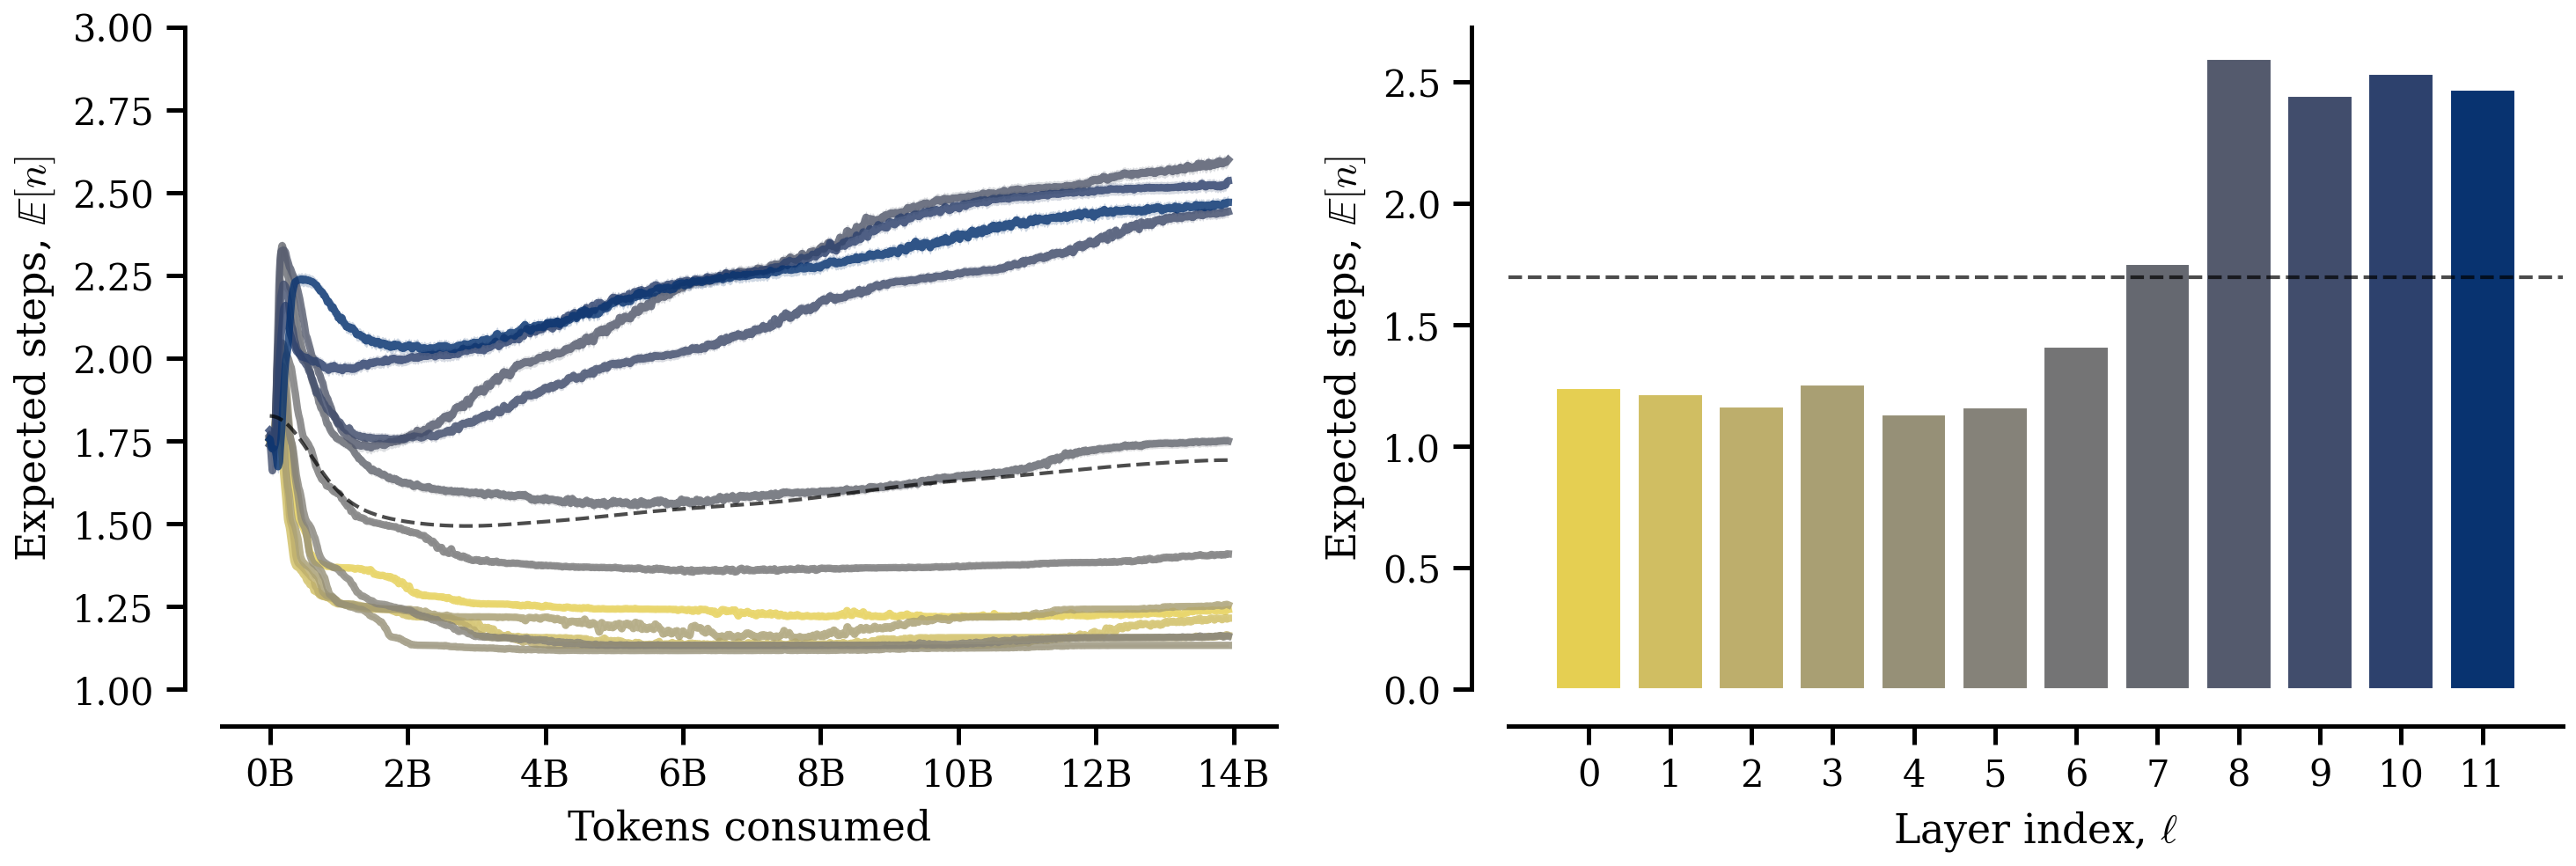

In [5]:
ponder_data = get_layer_metric('ponder_cost')

if not ponder_data.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    layer_colors = get_layer_colors(NUM_LAYERS)
    
    # (A) Lines over training (X-axis = Tokens)
    ax = axes[0]
    layer_cols = [c for c in ponder_data.columns if c not in ['step', 'tokens']]
    
    # 1. Plot individual layers
    for i, col in enumerate(layer_cols):
        plot_with_band(ax, ponder_data['tokens'], ponder_data[col], 
                      color=layer_colors[i], smooth_sigma=20, alpha_line=0.8)
    # Calculate the mean across all layer columns for each step
    avg_ponder = ponder_data[layer_cols].mean(axis=1)
    
    plot_with_band(ax, ponder_data['tokens'], avg_ponder, no_band=True, 
                   color='black', linestyle='--', linewidth=1.0, 
                   label='Average', smooth_sigma=1000, alpha_line=0.7)
    
    ax.set_ylim([1, MAX_LOOPS])
    
    # Apply Billions formatting
    ax.xaxis.set_major_formatter(FuncFormatter(billions))
    
    ax.set_xlabel(r'Tokens consumed')
    ax.set_ylabel(r'Expected steps, $\mathbb{E}[n]$')
    
    # (B) Bar chart (final values)
    ax = axes[1]
    final = ponder_data.drop(columns=['step', 'tokens'], errors='ignore').iloc[-100:].mean()
    
    x = np.arange(len(final))
    ax.bar(x, final.values, color=layer_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(final.mean(), color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel(r'Layer index, $\ell$')
    ax.set_ylabel(r'Expected steps, $\mathbb{E}[n]$')
    ax.set_xticks(x)
    
    despine(axes)
    plt.tight_layout()
    save_figure(fig, 'layer_computation', FIGURES_DIR)
    plt.show()

---
## 2. Convergence-Halting Correlation

**Question:** Does high cosine similarity (converged representation) predict halting?

  → Saved: convergence_halting_all_loops.{pdf, png}


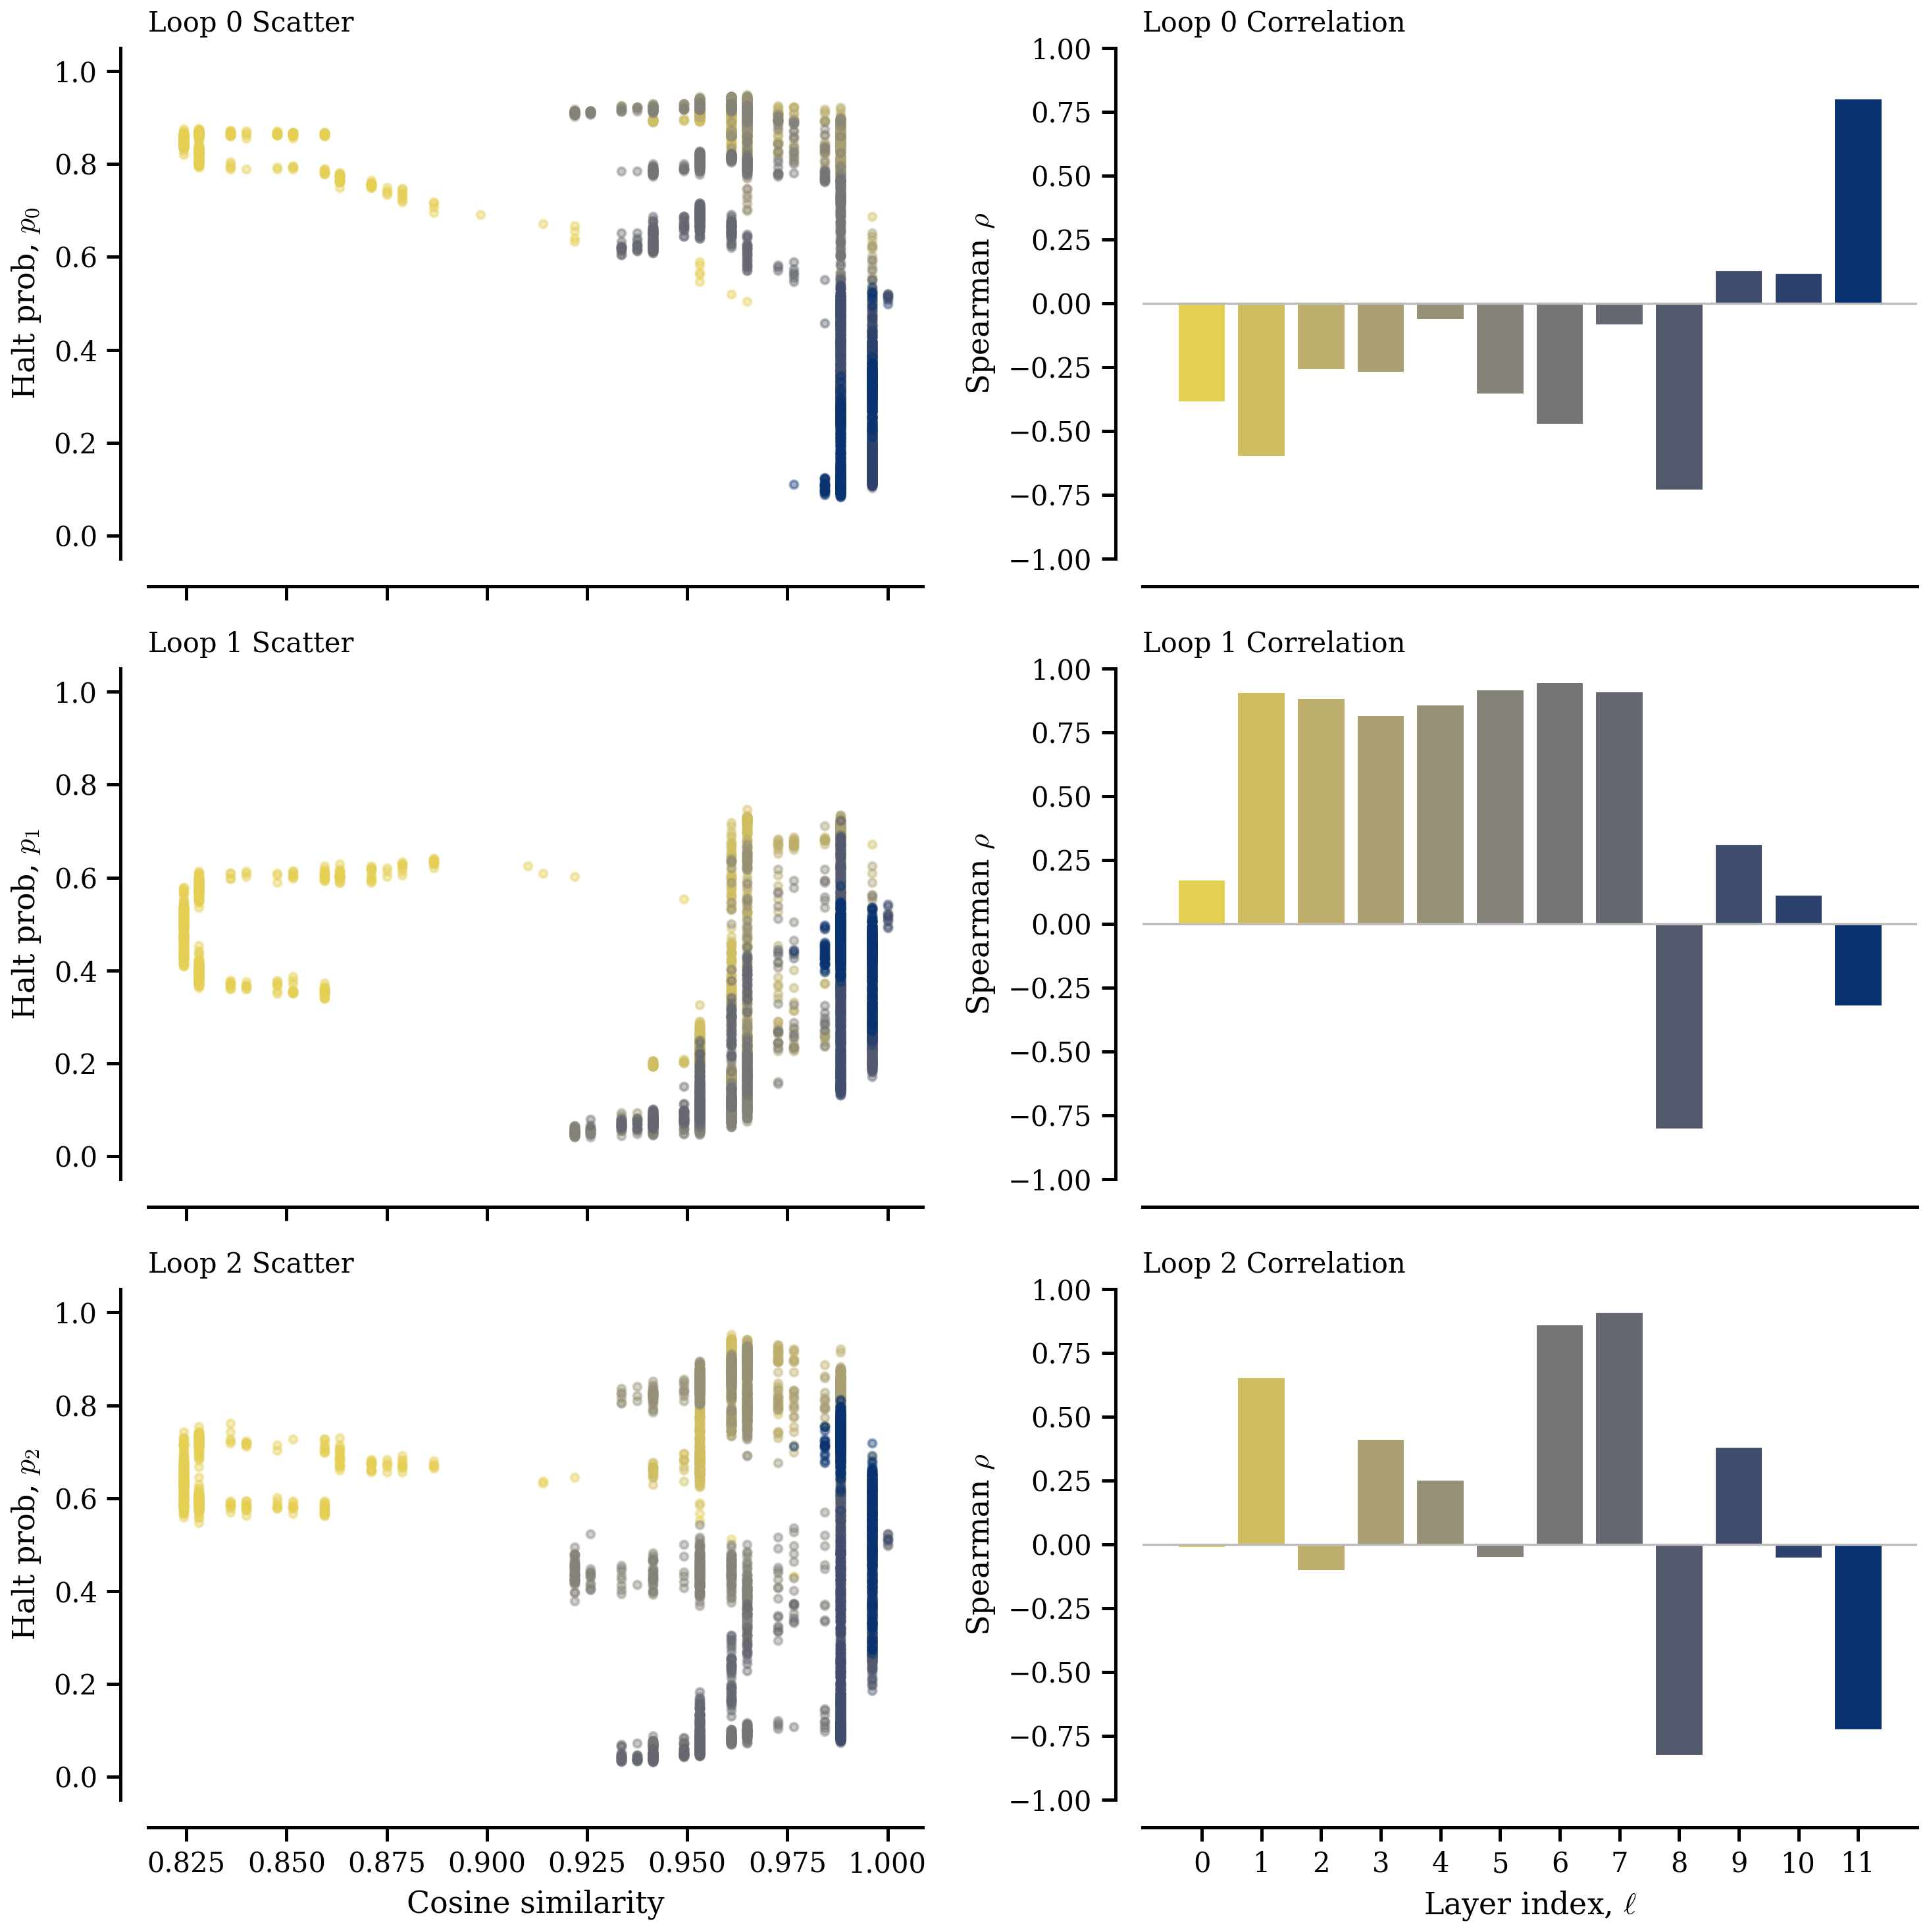

In [9]:
# === LOAD DATA FOR ALL LOOPS ===
cos_sim_data = get_layer_metric('cos_sim')
halt_probs = [get_layer_metric(f'halt_prob_{t}') for t in range(MAX_LOOPS)]

# Only proceed if we have data
if not cos_sim_data.empty and all(not h.empty for h in halt_probs):
    
    # Create 3 rows (one for each loop iteration) x 2 columns
    fig, axes = plt.subplots(MAX_LOOPS, 2, figsize=(10, 10))
    layer_colors = get_layer_colors(NUM_LAYERS)
    
    for t in range(MAX_LOOPS):
        halt_data = halt_probs[t]
        
        # --- (Left Column) Scatter Plot ---
        ax_scatter = axes[t, 0]
        for i in range(NUM_LAYERS):
            col = f'Layer {i}'
            if col in cos_sim_data.columns and col in halt_data.columns:
                c = cos_sim_data[col].dropna().values
                h = halt_data[col].dropna().values
                
                # Downsample for scatter visibility if needed
                n = min(len(c), len(h))
                if n > 0:
                    idx = np.random.choice(n, min(500, n), replace=False)
                    ax_scatter.scatter(c[idx], h[idx], color=layer_colors[i], 
                                     alpha=0.4, s=8, rasterized=True)
        
        ax_scatter.set_ylabel(rf'Halt prob, $p_{t}$')
        if t == MAX_LOOPS - 1:
            ax_scatter.set_xlabel(r'Cosine similarity')
        else:
            ax_scatter.set_xticklabels([]) # Hide x-ticks for top rows
            
        ax_scatter.set_title(rf'Loop {t} Scatter', loc='left', fontsize=10)
        ax_scatter.set_ylim(-0.05, 1.05)
        
        # --- (Right Column) Correlation Bar Chart ---
        ax_corr = axes[t, 1]
        correlations = []
        for i in range(NUM_LAYERS):
            col = f'Layer {i}'
            if col in cos_sim_data.columns and col in halt_data.columns:
                c = cos_sim_data[col].dropna()
                h = halt_data[col].dropna()
                n = min(len(c), len(h))
                
                if n > 10:
                    # Spearman correlation
                    r, _ = stats.spearmanr(c.iloc[:n], h.iloc[:n])
                    correlations.append(r)
                else:
                    correlations.append(np.nan)
        
        x = np.arange(len(correlations))
        ax_corr.bar(x, correlations, color=layer_colors, edgecolor='white', linewidth=0.5)
        ax_corr.axhline(0, color=COLORS['grey'], ls='-', lw=0.8)
        
        ax_corr.set_ylabel(r'Spearman $\rho$')
        ax_corr.set_ylim(-1.0, 1.0) # Fix y-scale for easy comparison
        
        if t == MAX_LOOPS - 1:
            ax_corr.set_xlabel(r'Layer index, $\ell$')
            ax_corr.set_xticks(x)
        else:
            ax_corr.set_xticks([])
            
        ax_corr.set_title(rf'Loop {t} Correlation', loc='left', fontsize=10)

    despine(axes.flatten())
    plt.tight_layout()
    save_figure(fig, 'convergence_halting_all_loops', FIGURES_DIR)
    plt.show()

  → Saved: fig_memory_stability_connected_scatter.{pdf, png}


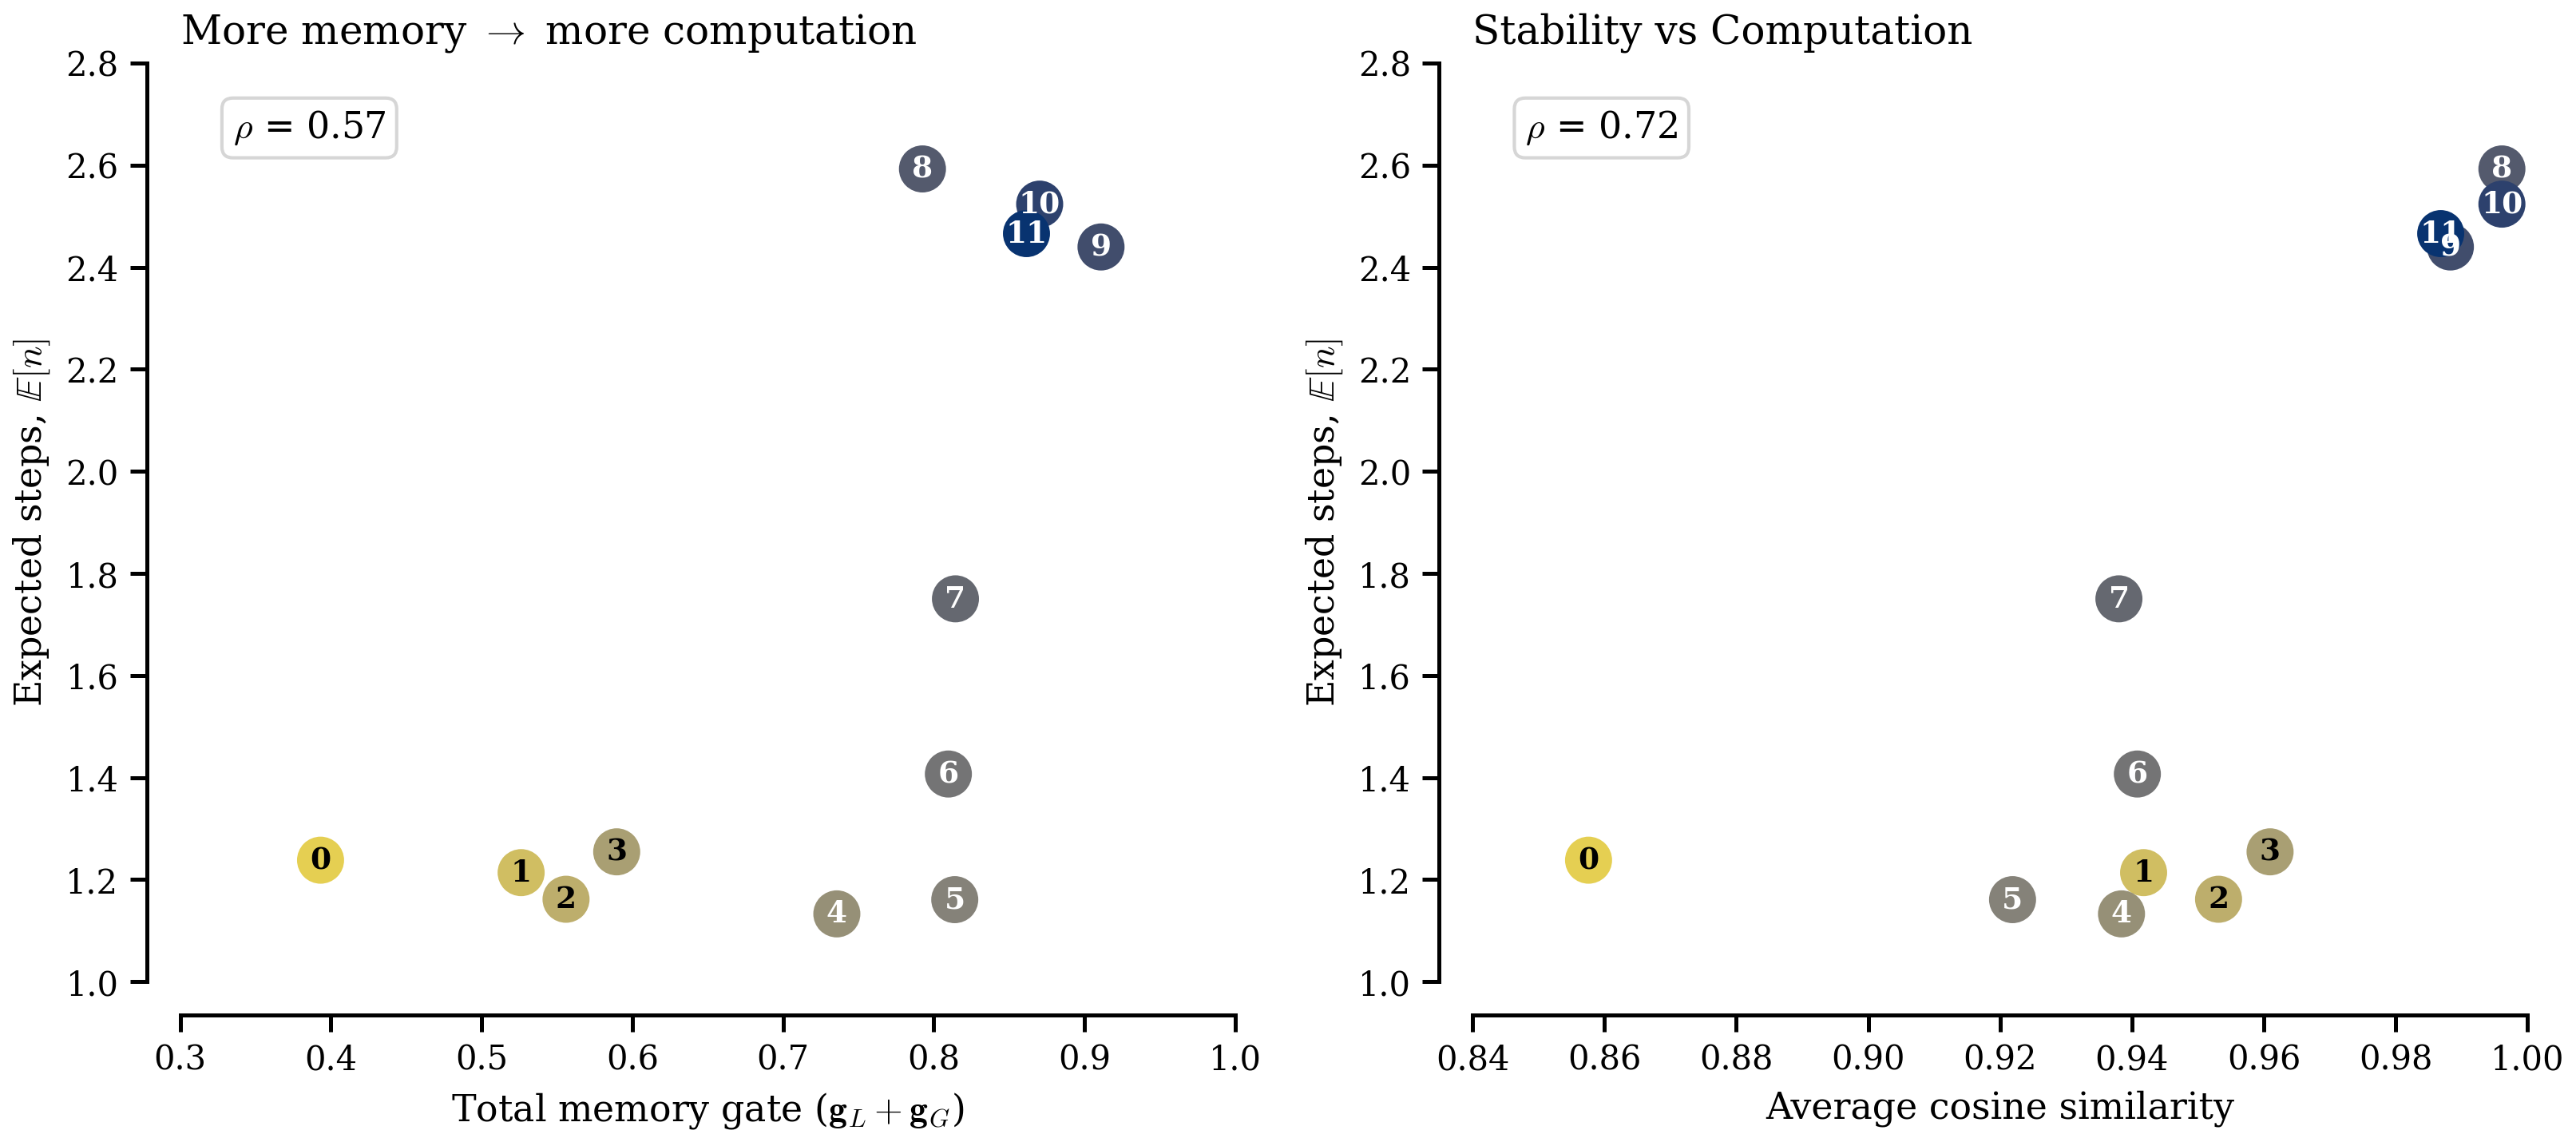

In [61]:
import matplotlib.colors as mcolors

# --- Helper: Text Color based on background luminance ---
def get_text_color(color_code):
    rgb = mcolors.to_rgb(color_code)
    # Calculate luminance (standard formula)
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.6 else 'white'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Data Extraction ---
local_mem_avg = []
global_mem_avg = []
ponder_avg = []
cos_sim_avg = []

for layer_idx in range(NUM_LAYERS):
    local_col = f'train layers/{layer_idx}/local_mem_scale'
    global_col = f'train layers/{layer_idx}/global_mem_scale'
    ponder_col = f'train layers/{layer_idx}/ponder_cost'
    cos_col = f'train layers/{layer_idx}/cos_sim'
    
    # Using last 500 steps mean, defaulting to 0 if missing
    local_mem_avg.append(df_stable[local_col].iloc[-500:].mean() if local_col in df_stable.columns else 0)
    global_mem_avg.append(df_stable[global_col].iloc[-500:].mean() if global_col in df_stable.columns else 0)
    ponder_avg.append(df_stable[ponder_col].iloc[-500:].mean() if ponder_col in df_stable.columns else 0)
    cos_sim_avg.append(df_stable[cos_col].iloc[-500:].mean() if cos_col in df_stable.columns else 0)

total_mem = np.array(local_mem_avg) + np.array(global_mem_avg)

# --- Shared Plotting Function ---
def plot_connected_scatter(ax, x_data, y_data, colors, x_label):
    # 1. Min/Max Horizontal Lines (for Y-axis/Steps)
    y_min, y_max = np.min(y_data), np.max(y_data)
    
    # 2. Connecting Line (Layer 0 -> Layer L)
    # This visualizes the trajectory through layers
    # ax.plot(x_data, y_data, color='gray', alpha=0.3, linewidth=1, zorder=1)
    
    # 3. Scatter Points
    ax.scatter(x_data, y_data, c=colors, s=200, edgecolor='none', zorder=2)
    
    # 4. Numbers inside points with contrast color
    for i, (x, y) in enumerate(zip(x_data, y_data)):
        txt_color = get_text_color(colors[i])
        ax.annotate(str(i), (x, y), fontsize=9, ha='center', va='center',
                    color=txt_color, fontweight='bold', zorder=3)
        
    # 5. Trend Line (keeping from original request for statistical context)
    # z = np.polyfit(x_data, y_data, 1)
    # p = np.poly1d(z)
    # x_line = np.linspace(min(x_data), max(x_data), 100)
    # ax.plot(x_line, p(x_line), '--', color=COLORS['grey'], linewidth=1.5, alpha=0.6, zorder=1)

    # 6. Correlation Box
    r, pval = stats.spearmanr(x_data, y_data)
    ax.text(0.05, 0.95, rf'$\rho$ = {r:.2f}', transform=ax.transAxes, va='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#cccccc'))

    ax.set_xlabel(x_label)
    ax.set_ylabel(r'Expected steps, $\mathbb{E}[n]$')
    ax.set_ylim([1, 2.8])

# --- Left Plot: Total Memory vs Steps ---
plot_connected_scatter(
    axes[0], 
    total_mem, 
    ponder_avg, 
    layer_colors[:len(total_mem)],
    r'Total memory gate ($\mathbf{g}_L + \mathbf{g}_G$)'
)
axes[0].set_title(r'More memory $\rightarrow$ more computation', loc='left')
axes[0].set_xlim([0.3, 1.0])

# --- Right Plot: Cosine Similarity vs Steps ---
plot_connected_scatter(
    axes[1], 
    cos_sim_avg, 
    ponder_avg, 
    layer_colors[:len(cos_sim_avg)],
    r'Average cosine similarity'
)
axes[1].set_title(r'Stability vs Computation', loc='left')
axes[1].set_xlim([0.84, 1.0])

despine(axes)
plt.tight_layout()
save_figure(fig, 'fig_memory_stability_connected_scatter', FIGURES_DIR)
plt.show()

In [16]:
# === CONFIGURATION ===
WARMUP_STEPS = 5000  # Discard first N steps

# Filter dataframe
df_stable = df[df['step'] >= WARMUP_STEPS].copy()
print(f"Using {len(df_stable)} steps (discarded first {WARMUP_STEPS})")

Using 33621 steps (discarded first 5000)


  → Saved: fig_binned_halt_vs_memory.{pdf, png}


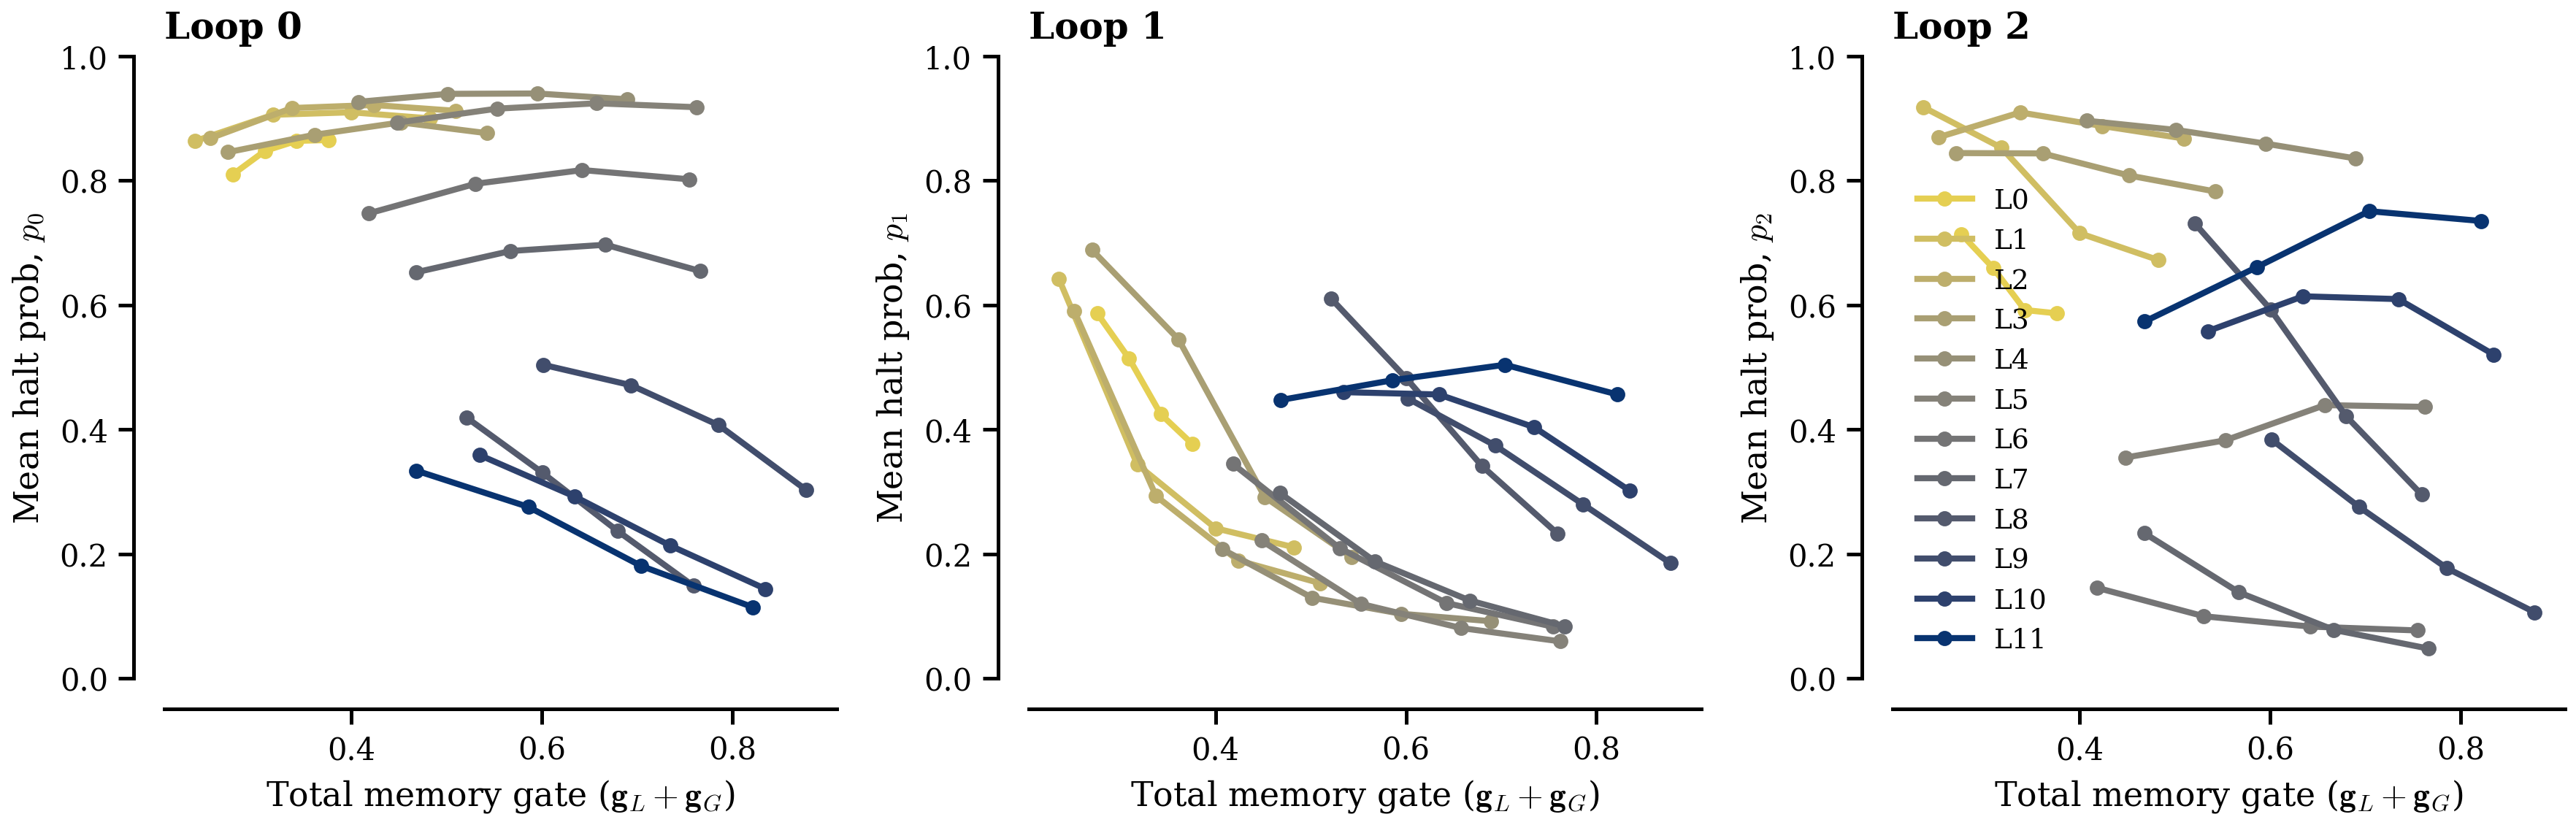

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Select representative layers
rep_layers = np.arange(0, NUM_LAYERS)
rep_colors = [layer_colors[i] for i in rep_layers]

for loop_idx, ax in enumerate(axes):
    for layer_idx, color in zip(rep_layers, rep_colors):
        local_col = f'train layers/{layer_idx}/local_mem_scale'
        global_col = f'train layers/{layer_idx}/global_mem_scale'
        halt_col = f'train layers/{layer_idx}/halt_prob_{loop_idx}'
        
        # Total memory
        mem = df_stable[local_col].values + df_stable[global_col].values
        halt = df_stable[halt_col].values
        mask = ~(np.isnan(mem) | np.isnan(halt))
        
        # Bin by memory gate
        n_bins = 5
        mem_bins = np.linspace(np.nanpercentile(mem, 2), np.nanpercentile(mem, 98), n_bins)
        bin_centers = (mem_bins[:-1] + mem_bins[1:]) / 2
        
        binned_mean = []
        binned_sem = []
        
        for i in range(len(mem_bins) - 1):
            in_bin = (mem >= mem_bins[i]) & (mem < mem_bins[i+1]) & mask
            if in_bin.sum() > 20:
                binned_mean.append(np.mean(halt[in_bin]))
                binned_sem.append(np.std(halt[in_bin]) / np.sqrt(in_bin.sum()))
            else:
                binned_mean.append(np.nan)
                binned_sem.append(np.nan)
        
        binned_mean = np.array(binned_mean)
        binned_sem = np.array(binned_sem)
        
        ax.fill_between(bin_centers, binned_mean - binned_sem, binned_mean + binned_sem,
                       color=color, alpha=0.2, linewidth=0)
        ax.plot(bin_centers, binned_mean, 'o-', color=color, linewidth=2, 
               markersize=4, label=f'L{layer_idx}')
    
    ax.set_xlabel(r'Total memory gate ($\mathbf{g}_L + \mathbf{g}_G$)')
    ax.set_ylabel(rf'Mean halt prob, $p_{loop_idx}$')
    ax.set_title(f'Loop {loop_idx}', loc='left', fontweight='bold')
    ax.set_ylim(0, 1)
    if loop_idx == 2:
        ax.legend(fontsize=9)

despine(axes)
plt.tight_layout()
save_figure(fig, 'fig_binned_halt_vs_memory', FIGURES_DIR)
plt.show()

  → Saved: halt_prob_distribution.{pdf, png}


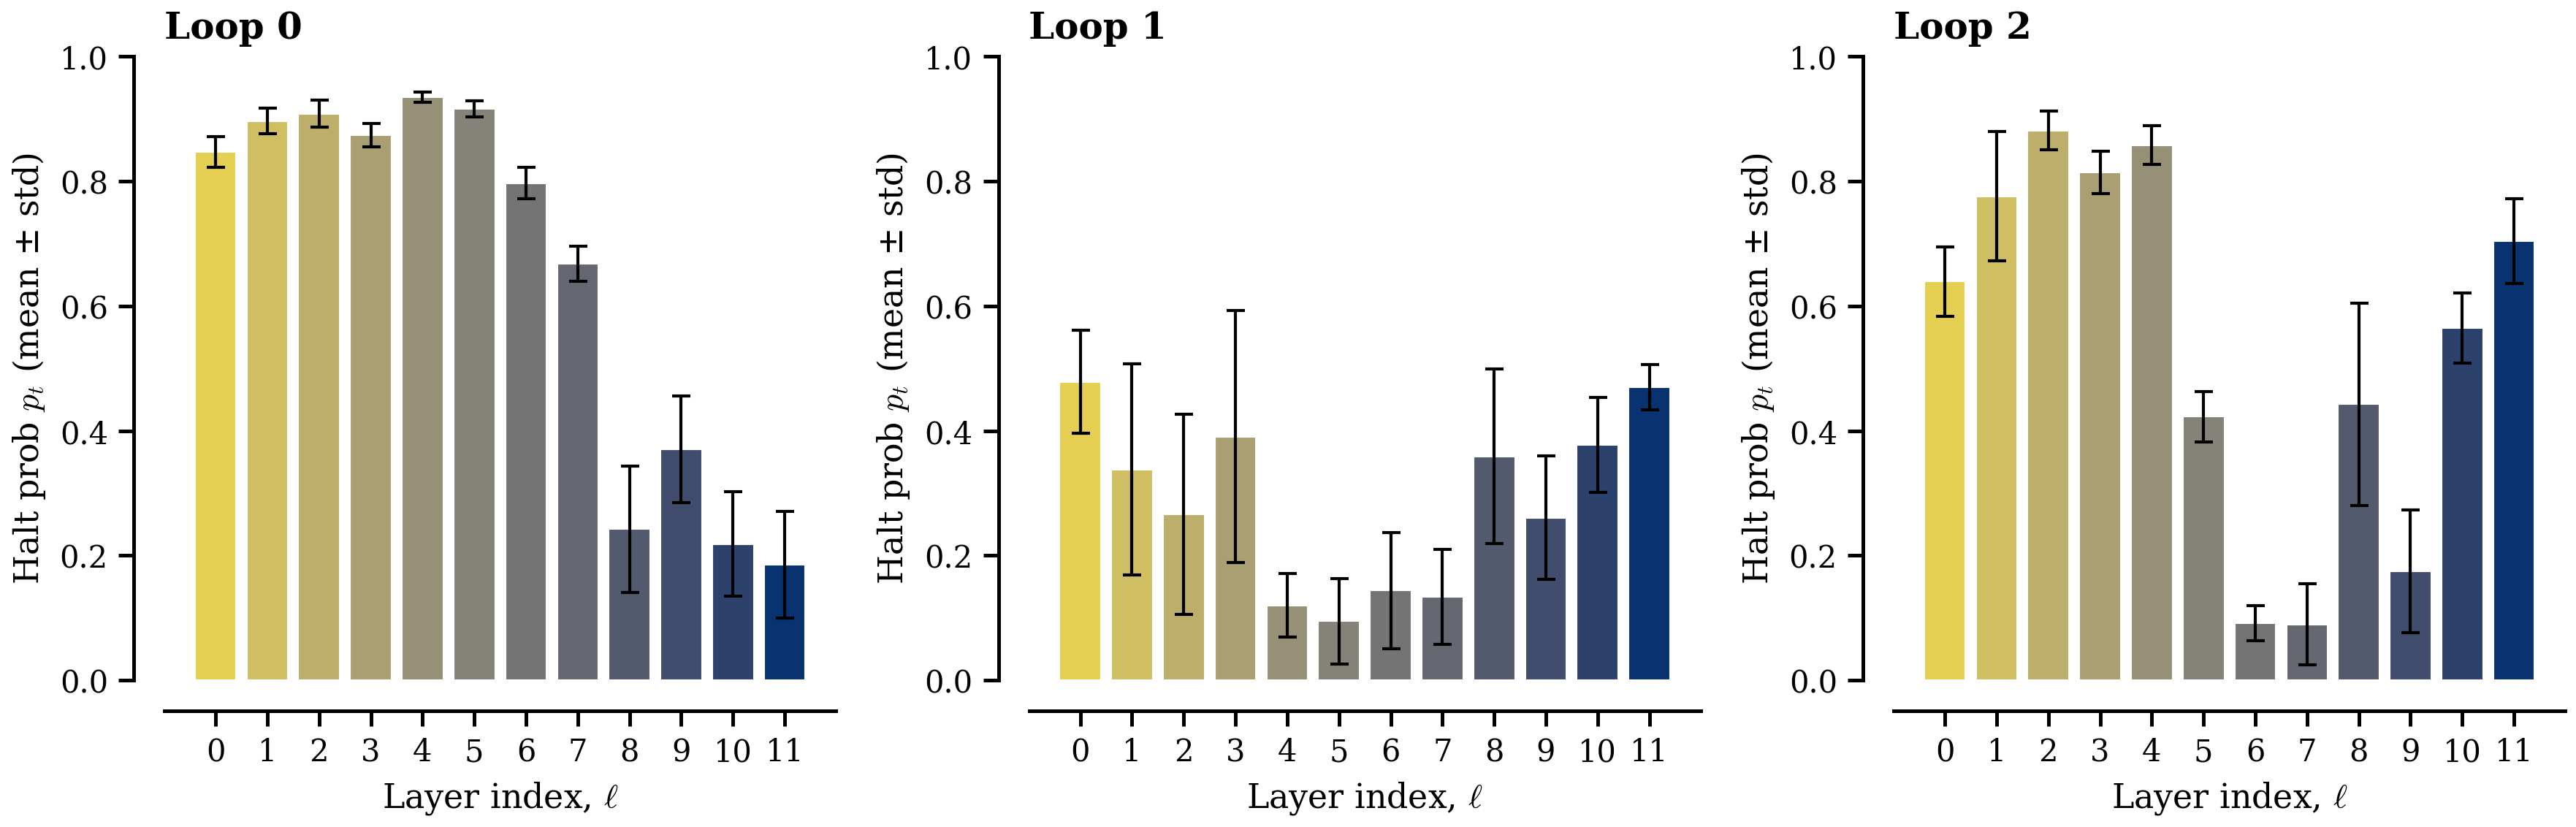

In [19]:
# Check variance of halt probability across training for each layer
# High variance = halt decision depends on training state
# Low variance = halt decision is consistent

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for loop_idx, ax in enumerate(axes):
    means = []
    stds = []
    
    for layer_idx in range(NUM_LAYERS):
        halt_col = f'train layers/{layer_idx}/halt_prob_{loop_idx}'
        if halt_col in df_stable.columns:
            data = df_stable[halt_col].dropna()
            means.append(data.mean())
            stds.append(data.std())
    
    x = np.arange(len(means))
    ax.bar(x, means, yerr=stds, color=layer_colors, edgecolor='white', 
           linewidth=0.5, capsize=3, error_kw={'linewidth': 1})
    ax.set_xlabel(r'Layer index, $\ell$')
    ax.set_ylabel(r'Halt prob $p_t$ (mean ± std)')
    ax.set_title(f'Loop {loop_idx}', loc='left', fontweight='bold')
    ax.set_xticks(x)
    ax.set_ylim(0, 1)

despine(axes)
plt.tight_layout()
save_figure(fig, 'halt_prob_distribution', FIGURES_DIR)
plt.show()

  → Saved: halt_prob_evolution.{pdf, png}


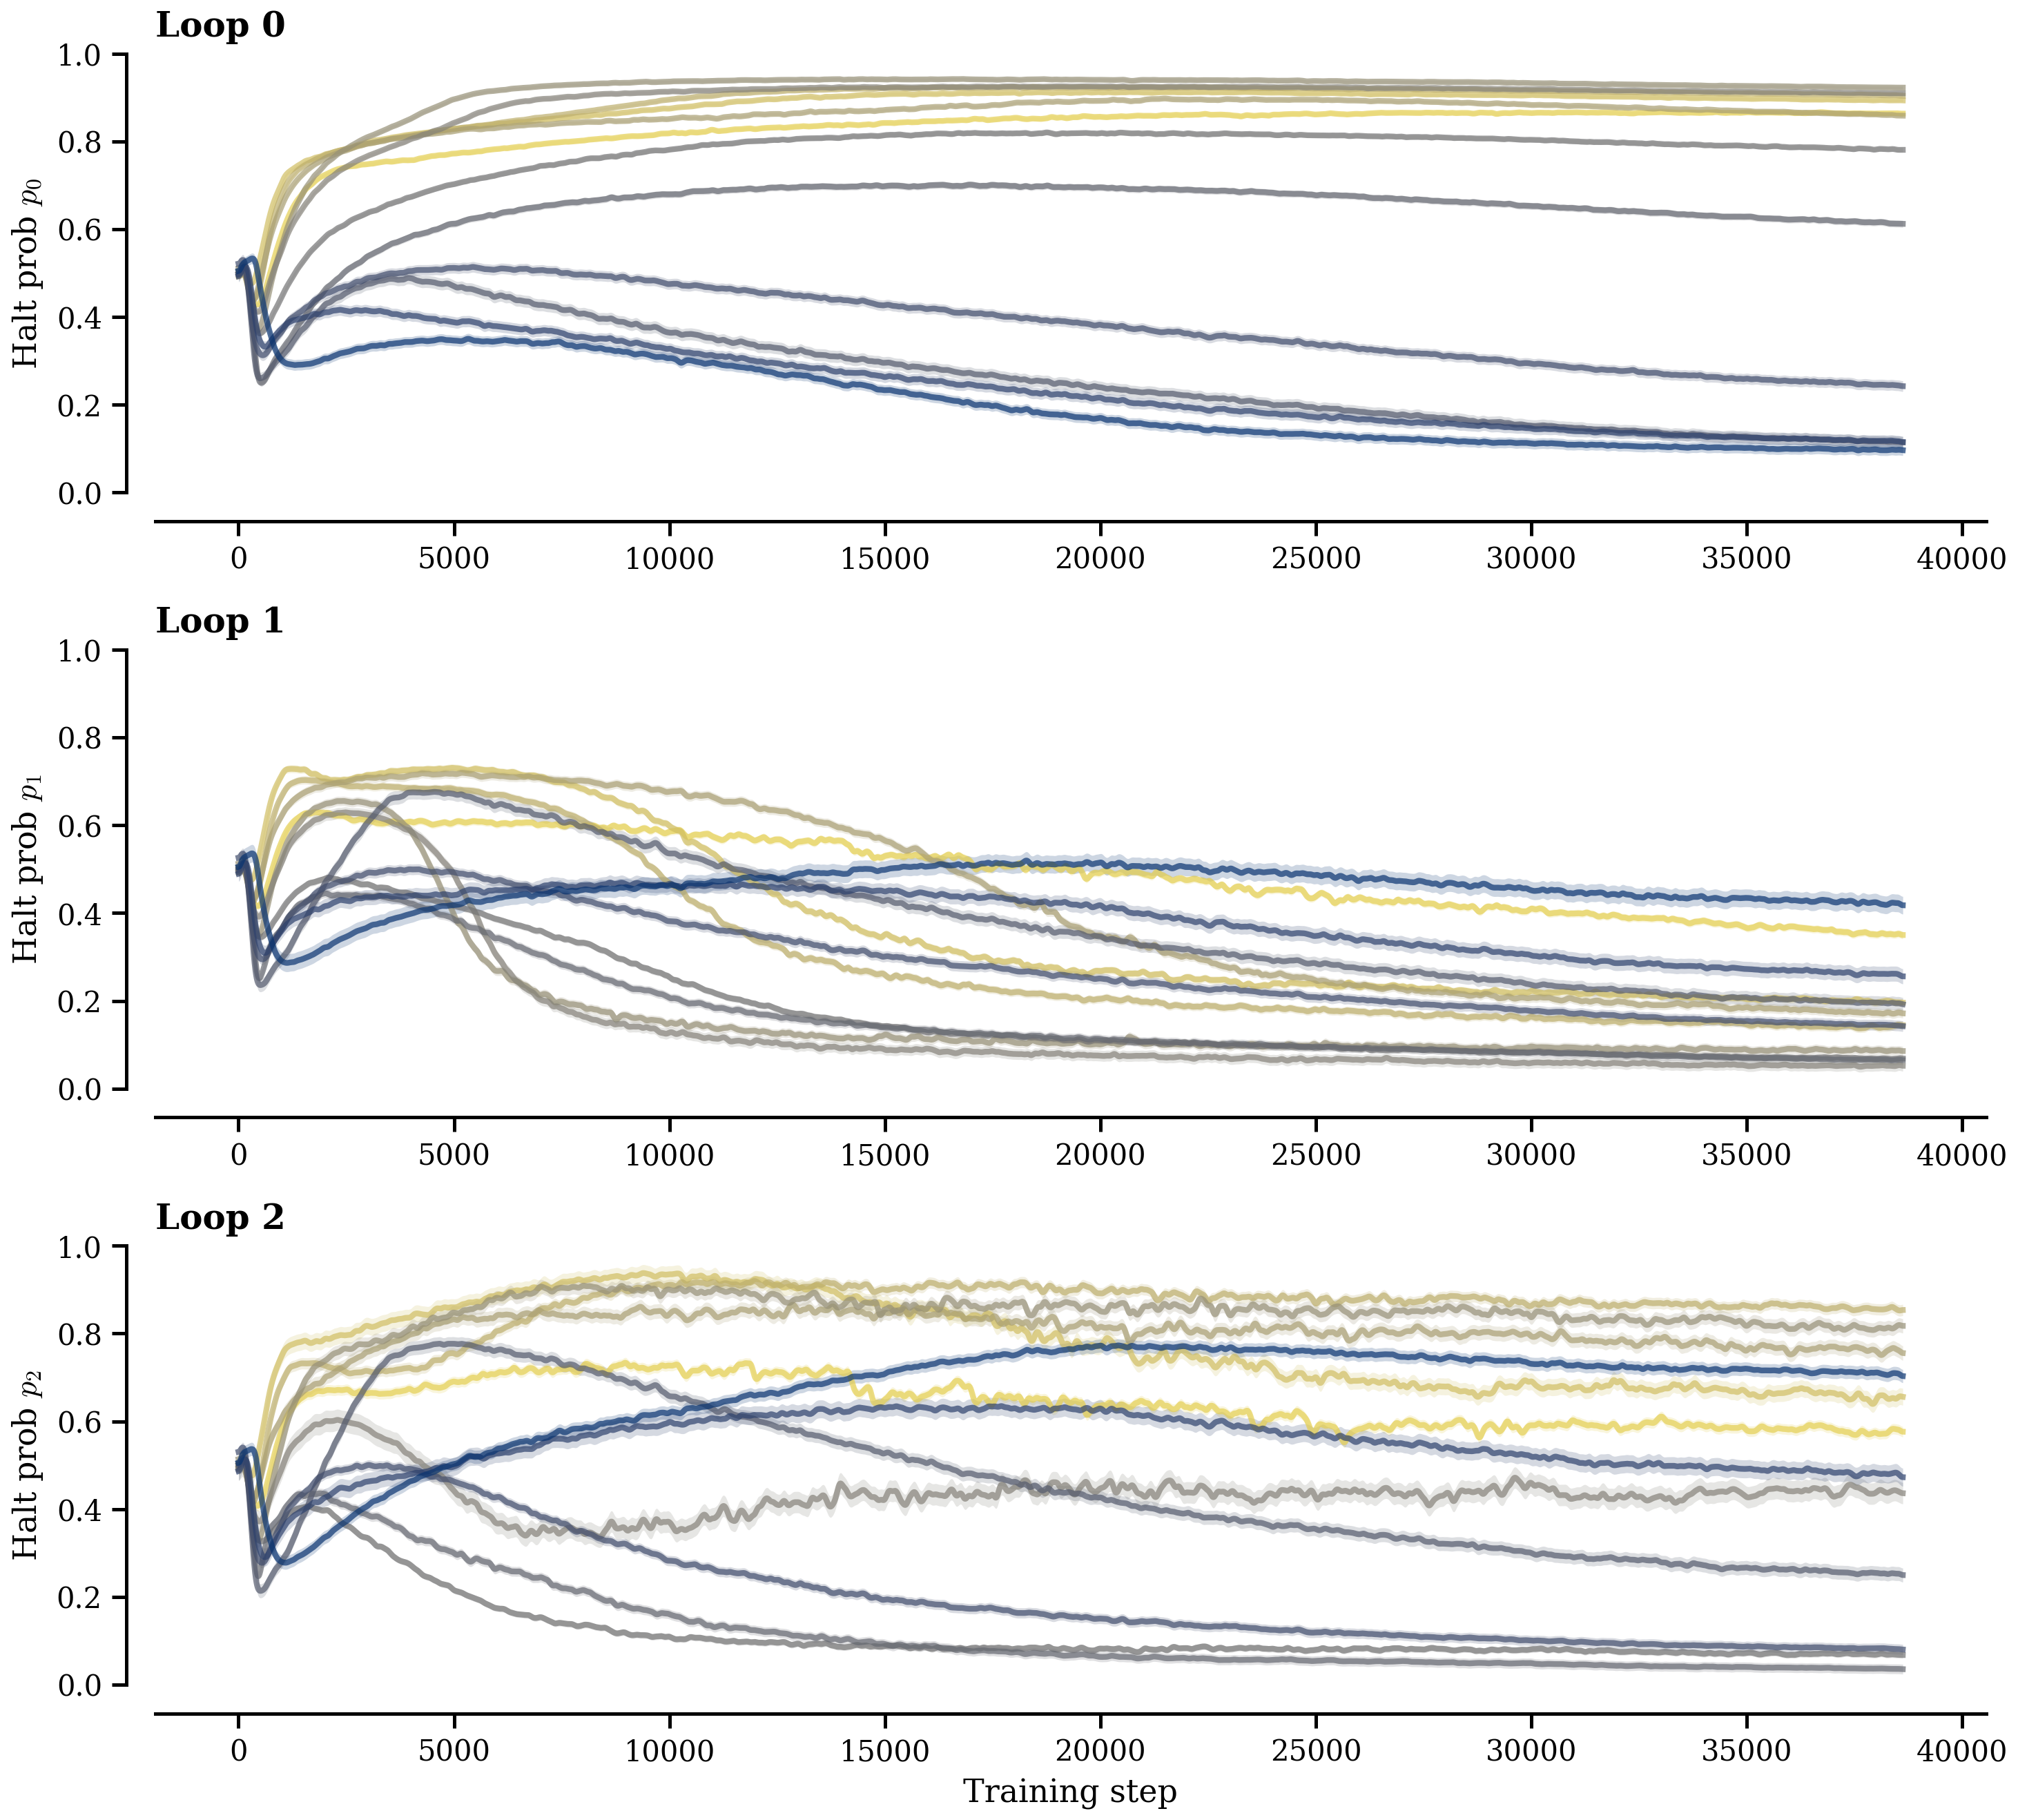

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for loop_idx, ax in enumerate(axes):
    for layer_idx in range(NUM_LAYERS):
        halt_col = f'train layers/{layer_idx}/halt_prob_{loop_idx}'
        if halt_col in df.columns:  # Use full df to see warm-up
            plot_with_band(ax, df['step'], df[halt_col], layer_colors[layer_idx],
                          smooth_sigma=50, alpha_line=0.7)
    ax.set_ylabel(rf'Halt prob $p_{loop_idx}$')
    ax.set_title(f'Loop {loop_idx}', loc='left', fontweight='bold')
    ax.set_ylim(0, 1)

axes[-1].set_xlabel('Training step')
axes[0].legend(loc='upper right')

despine(axes)
plt.tight_layout()
save_figure(fig, 'halt_prob_evolution', FIGURES_DIR)
plt.show()

---
## 3. Memory Gate Dynamics

**Question:** When does memory become useful? Do layers prefer local vs global?

  → Saved: memory_gates.{pdf, png}


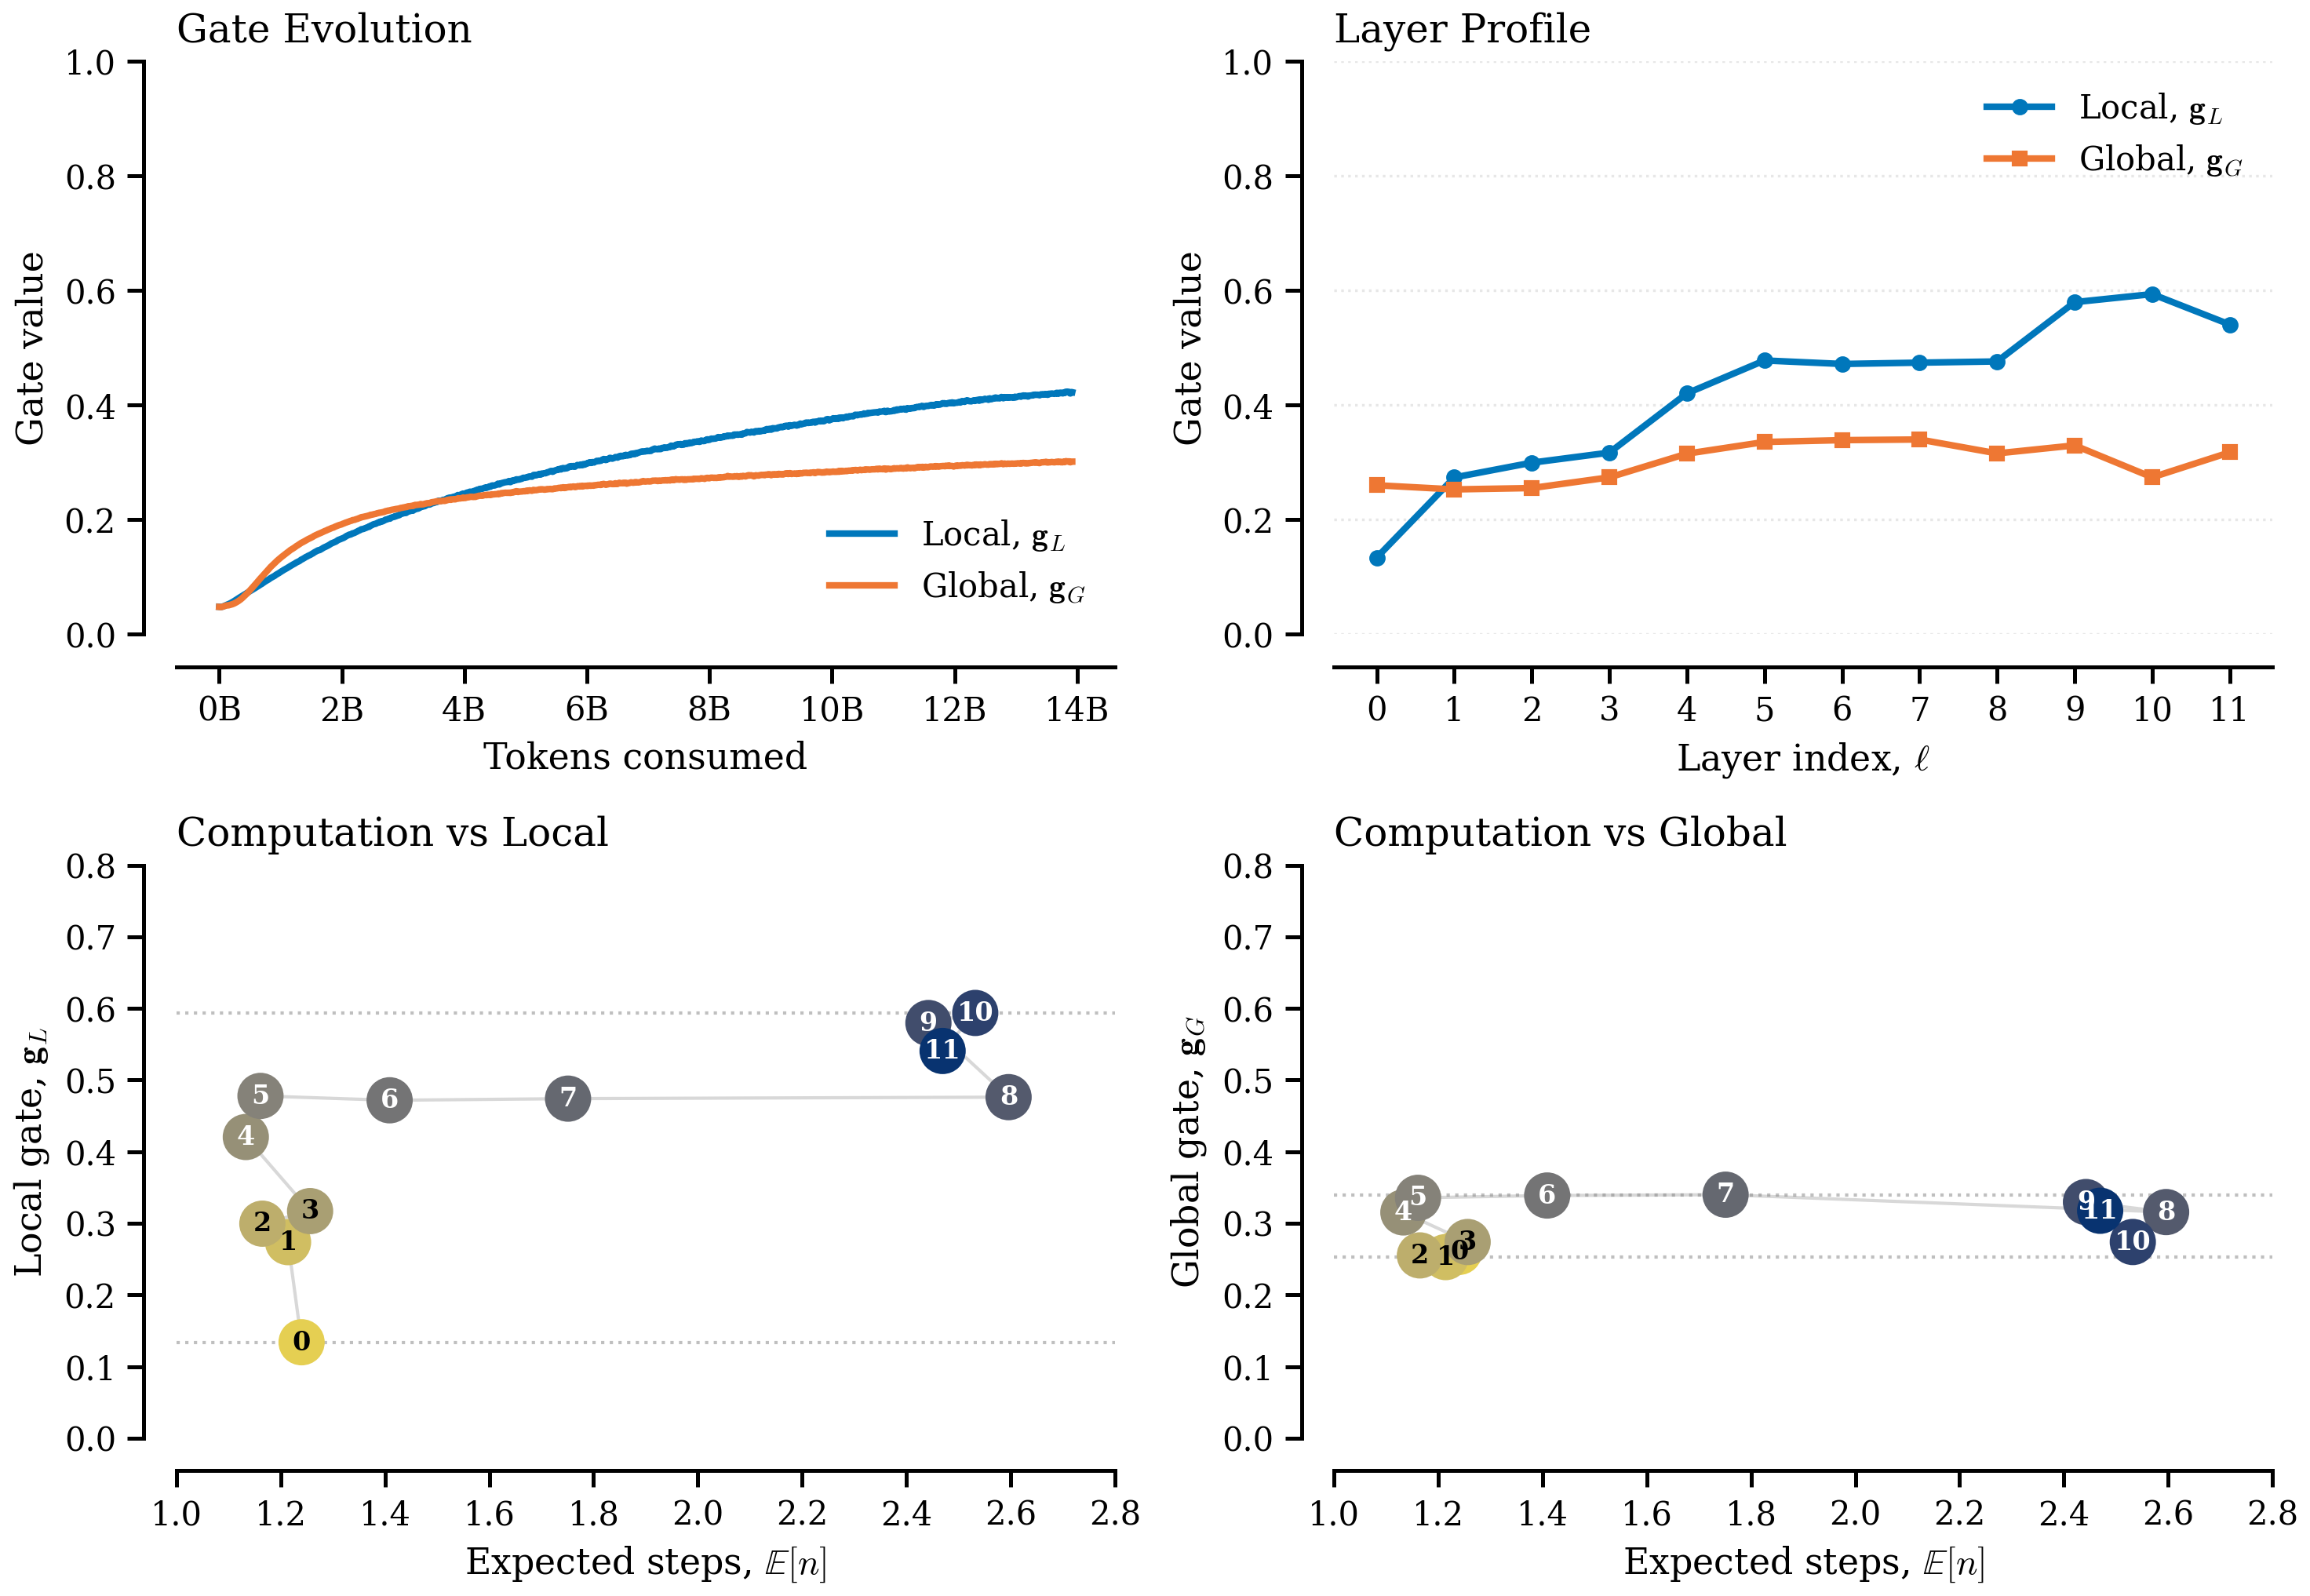

In [29]:
# %%
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
layer_colors = get_layer_colors(NUM_LAYERS)

# --- Data Prep ---
local_avg = safe_get('train adaptive/avg_local_mem_scale')
global_avg = safe_get('train adaptive/avg_global_mem_scale')

local_per_layer = get_layer_metric('local_mem_scale')
global_per_layer = get_layer_metric('global_mem_scale')
ponder_data = get_layer_metric('ponder_cost')

# Calculate final means per layer (last 100 steps)
if not local_per_layer.empty:
    final_local = local_per_layer.drop(columns=['step', 'tokens'], errors='ignore').iloc[-100:].mean()
if not global_per_layer.empty:
    final_global = global_per_layer.drop(columns=['step', 'tokens'], errors='ignore').iloc[-100:].mean()
if not ponder_data.empty:
    final_ponder = ponder_data.drop(columns=['step', 'tokens'], errors='ignore').iloc[-100:].mean()

# Helper: Choose text color based on background luminance
def get_text_color(color_code):
    rgb = mcolors.to_rgb(color_code)
    lum = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'black' if lum > 0.6 else 'white'

# --- (A) Gate opening over training (Time) ---
ax = axes[0, 0]
plot_with_band(ax, df['tokens'], local_avg, COLORS['blue'], 
               label=r'Local, $\mathbf{g}_L$', smooth_sigma=20)
plot_with_band(ax, df['tokens'], global_avg, COLORS['orange'], 
               label=r'Global, $\mathbf{g}_G$', smooth_sigma=20)
format_token_axis(ax)
ax.set_ylabel(r'Gate value')
ax.set_title(r'Gate Evolution', loc='left')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)

# --- (B) Per-layer Gates (Lines) ---
ax = axes[0, 1]
x = np.arange(NUM_LAYERS)

if not local_per_layer.empty and not global_per_layer.empty:
    ax.plot(x, final_local.values, color=COLORS['blue'], marker='o', markersize=4, 
            linewidth=2, label=r'Local, $\mathbf{g}_L$')
    ax.plot(x, final_global.values, color=COLORS['orange'], marker='s', markersize=4, 
            linewidth=2, label=r'Global, $\mathbf{g}_G$')

ax.set_xlabel(r'Layer index, $\ell$')
ax.set_ylabel(r'Gate value')
ax.set_title(r'Layer Profile', loc='left')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)

# --- Shared Plotting Function for C & D ---
def plot_scatter_connected(ax, x_data, y_data, title, y_label):
    n = min(len(x_data), len(y_data))
    
    # 1. Min/Max Horizontal Lines
    y_min, y_max = y_data.min(), y_data.max()
    ax.axhline(y_min, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(y_max, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # 2. Connecting Line (Layer 0 -> Layer L)
    ax.plot(x_data, y_data, color='gray', alpha=0.3, linewidth=1, zorder=1)
    
    # 3. Scatter Points with Text
    ax.scatter(x_data, y_data, c=layer_colors[:n], s=200, 
               edgecolor='none', zorder=2)
    
    for i in range(n):
        txt_color = get_text_color(layer_colors[i])
        ax.text(x_data[i], y_data[i], str(i), 
                ha='center', va='center', fontsize=8, 
                color=txt_color, fontweight='bold', zorder=3)

    ax.set_xlabel(r'Expected steps, $\mathbb{E}[n]$')
    ax.set_ylabel(y_label)
    ax.set_title(title, loc='left')
    # Add a bit of padding to y-axis to see the min/max lines clearly
    ax.set_ylim([0, 0.8])
    ax.set_xlim([1, 2.8])


# --- (C) Scatter: Ponder vs LOCAL ---
if not local_per_layer.empty and not ponder_data.empty:
    plot_scatter_connected(axes[1, 0], 
                           final_ponder.values, 
                           final_local.values, 
                           r'Computation vs Local', 
                           r'Local gate, $\mathbf{g}_L$')

# --- (D) Scatter: Ponder vs GLOBAL ---
if not global_per_layer.empty and not ponder_data.empty:
    plot_scatter_connected(axes[1, 1], 
                           final_ponder.values, 
                           final_global.values, 
                           r'Computation vs Global', 
                           r'Global gate, $\mathbf{g}_G$')

despine(axes)
plt.tight_layout()
save_figure(fig, 'memory_gates', FIGURES_DIR)
plt.show()

---
## 4. Loop Scale Evolution

  → Saved: loop_scales.{pdf, png}


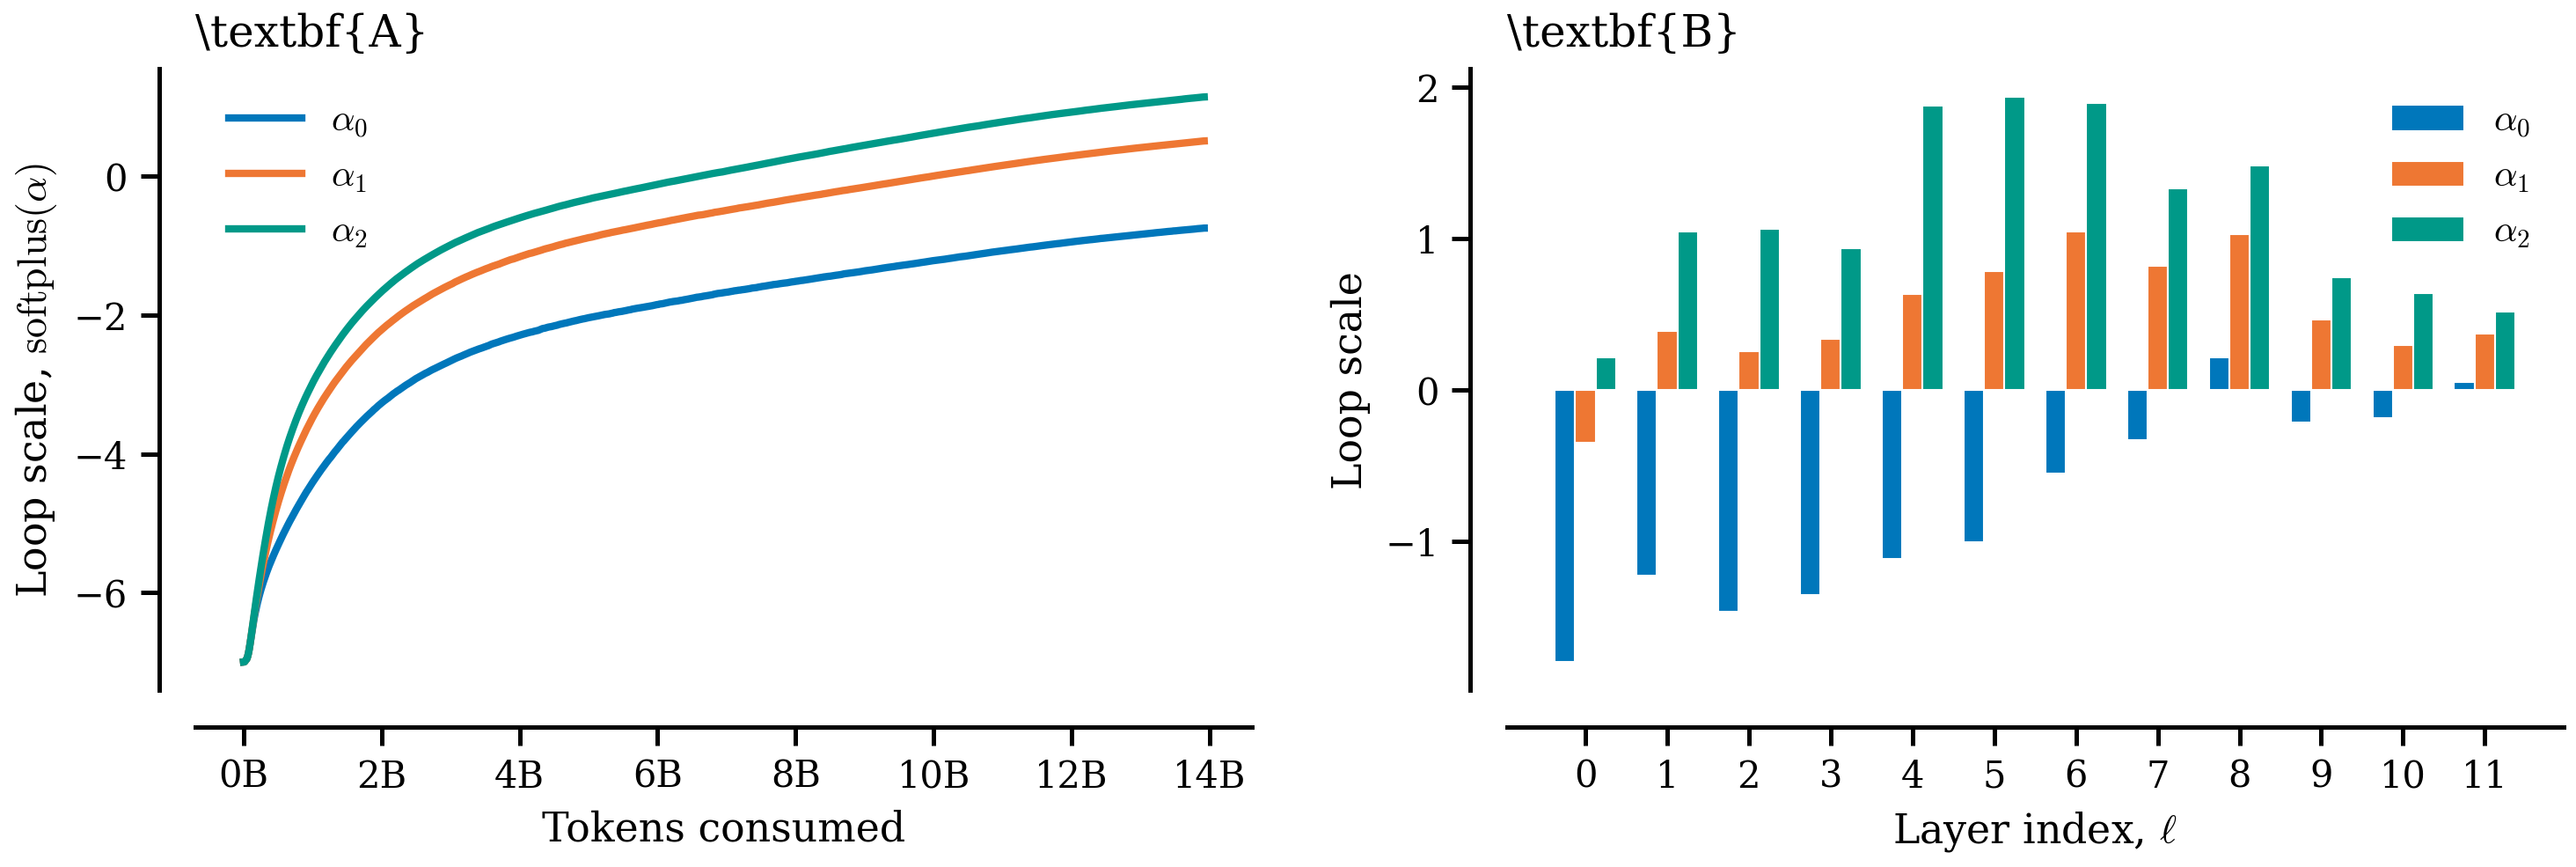

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
step_colors = [COLORS['blue'], COLORS['orange'], COLORS['teal']]

# (A) Average loop scale per step over training
ax = axes[0]
for t in range(MAX_LOOPS):
    col = f'train adaptive/avg_loop_scale_step_{t}'
    if col in df.columns:
        # === CHANGE: Use df['tokens'] ===
        plot_with_band(ax, df['tokens'], df[col], step_colors[t], 
                      label=rf'$\alpha_{t}$', smooth_sigma=20)
format_token_axis(ax) # === CHANGE: Apply formatter
ax.set_ylabel(r'Loop scale, $\mathrm{softplus}(\alpha)$')
ax.set_title(r'\textbf{A}', loc='left')
ax.legend()

# (B) Per-layer loop scales (grouped bar)
ax = axes[1]
x = np.arange(NUM_LAYERS)
width = 0.25
for t in range(MAX_LOOPS):
    data = get_layer_metric(f'loop_scale_{t}')
    if not data.empty:
        final = data.drop(columns=['step', 'tokens'], errors='ignore').iloc[-100:].mean().values
        ax.bar(x + t * width - width, final, width, 
               label=rf'$\alpha_{t}$', color=step_colors[t],
               edgecolor='white', linewidth=0.5)
ax.set_xlabel(r'Layer index, $\ell$')
ax.set_ylabel(r'Loop scale')
ax.set_title(r'\textbf{B}', loc='left')
ax.set_xticks(x)
ax.legend()

despine(axes)
plt.tight_layout()
save_figure(fig, 'loop_scales', FIGURES_DIR)
plt.show()

---
## 5. Loss Decomposition

  → Saved: loss_decomposition.{pdf, png}


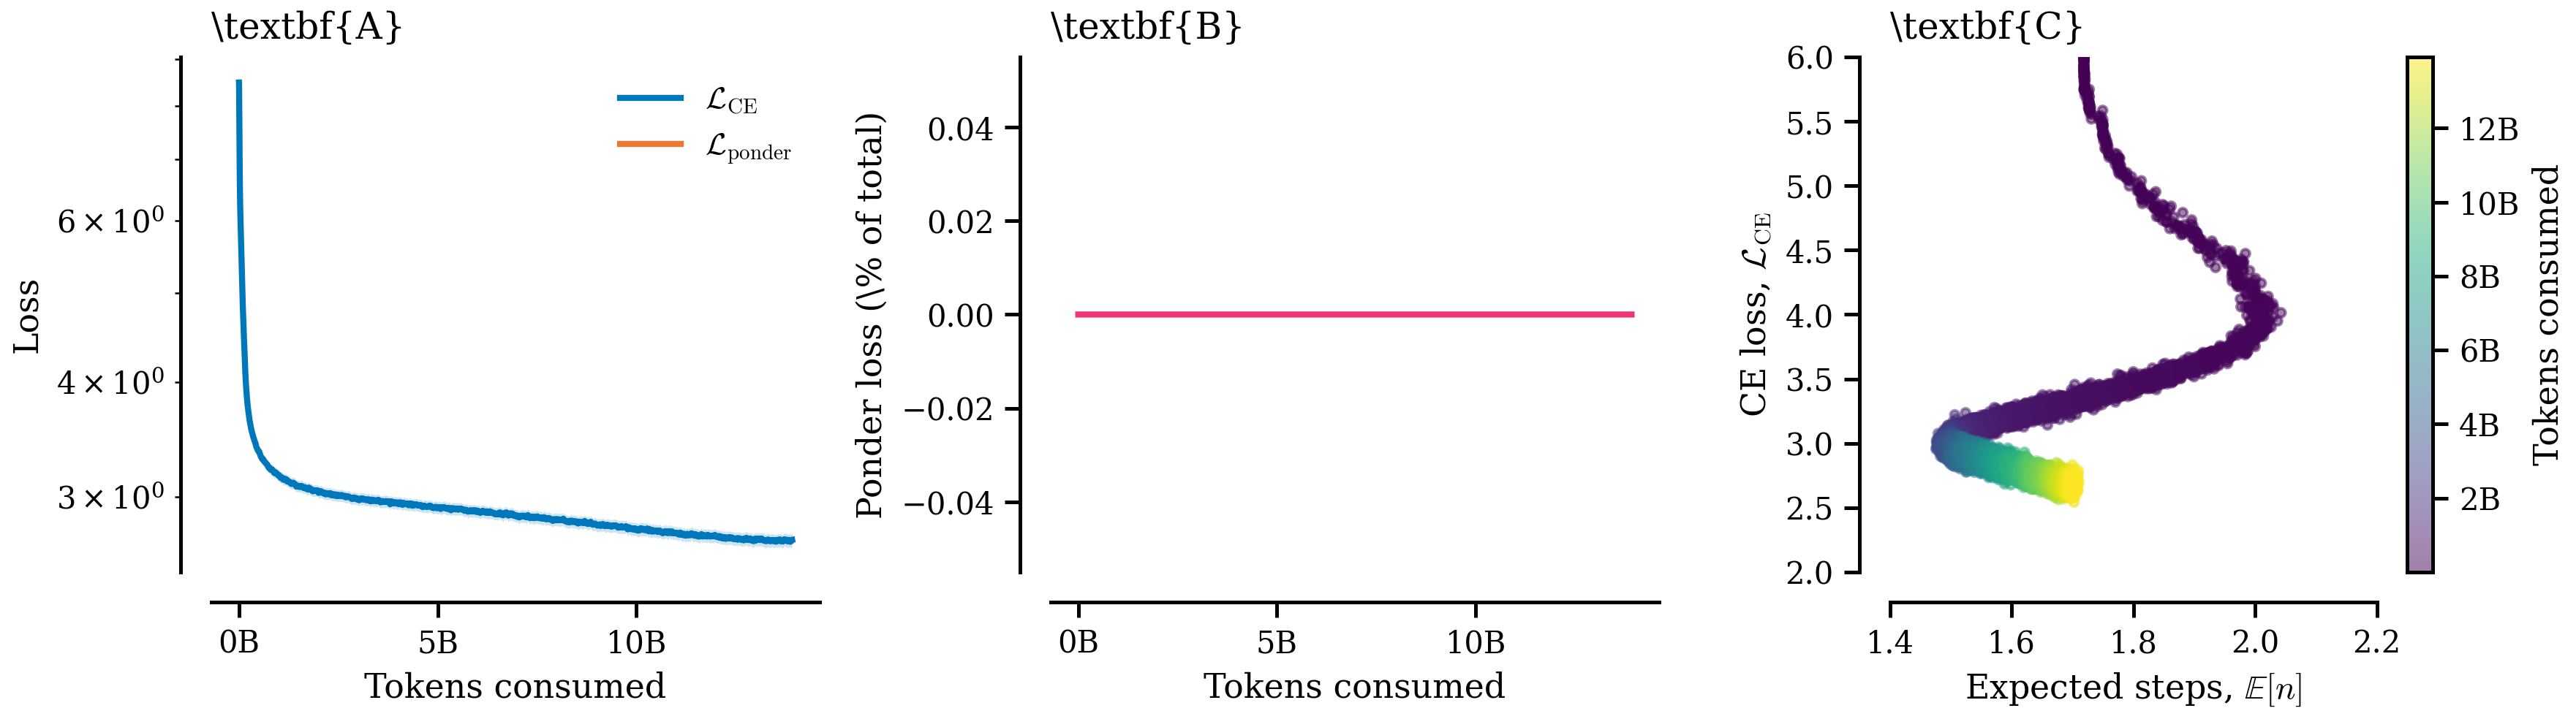

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

ce_loss = safe_get('train loss/ce_avg')
ponder_loss = safe_get('train ponder/loss_avg')
total_loss = safe_get('train loss/avg')
expected_steps = safe_get('train adaptive/expected_steps_avg')

# (A) Loss curves
ax = axes[0]
# === CHANGE: Use df['tokens'] ===
plot_with_band(ax, df['tokens'], ce_loss, COLORS['blue'], 
               label=r'$\mathcal{L}_{\mathrm{CE}}$', smooth_sigma=20)
plot_with_band(ax, df['tokens'], ponder_loss, COLORS['orange'], 
               label=r'$\mathcal{L}_{\mathrm{ponder}}$', smooth_sigma=20)
format_token_axis(ax) # === CHANGE: Apply formatter
ax.set_ylabel(r'Loss')
ax.set_title(r'\textbf{A}', loc='left')
ax.legend()
ax.set_yscale('log')

# (B) Ponder fraction
ax = axes[1]
mask = (total_loss > 0) & (~ponder_loss.isna())
frac = ponder_loss[mask] / total_loss[mask] * 100
# === CHANGE: Use df['tokens'] ===
x_valid = df['tokens'][mask].values
frac_smooth = smooth(frac.values, sigma=20)

ax.fill_between(x_valid, 0, frac_smooth, color=COLORS['magenta'], alpha=0.3, linewidth=0)
ax.plot(x_valid, frac_smooth, color=COLORS['magenta'], linewidth=2)
format_token_axis(ax) # === CHANGE: Apply formatter
ax.set_ylabel(r'Ponder loss (\% of total)')
ax.set_title(r'\textbf{B}', loc='left')

# (C) Pareto frontier (Colorbar now represents Tokens)
ax = axes[2]
mask = (~ce_loss.isna()) & (~expected_steps.isna())
# === CHANGE: Use tokens for color ===
scatter = ax.scatter(expected_steps[mask], ce_loss[mask], 
                    c=df['tokens'][mask], cmap='viridis', 
                    alpha=0.5, s=8, rasterized=True)
cbar = plt.colorbar(scatter, ax=ax)
# === CHANGE: Format colorbar ticks ===
cbar.ax.yaxis.set_major_formatter(FuncFormatter(billions))
cbar.set_label(r'Tokens consumed')

ax.set_ylim([2, 6])
ax.set_xlim([1.4, 2.2])
ax.set_xlabel(r'Expected steps, $\mathbb{E}[n]$')
ax.set_ylabel(r'CE loss, $\mathcal{L}_{\mathrm{CE}}$')
ax.set_title(r'\textbf{C}', loc='left')

despine(axes)
plt.tight_layout()
save_figure(fig, 'loss_decomposition', FIGURES_DIR)
plt.show()

---
## 6. Halt Probability Distribution

  → Saved: halt_distribution.{pdf, png}


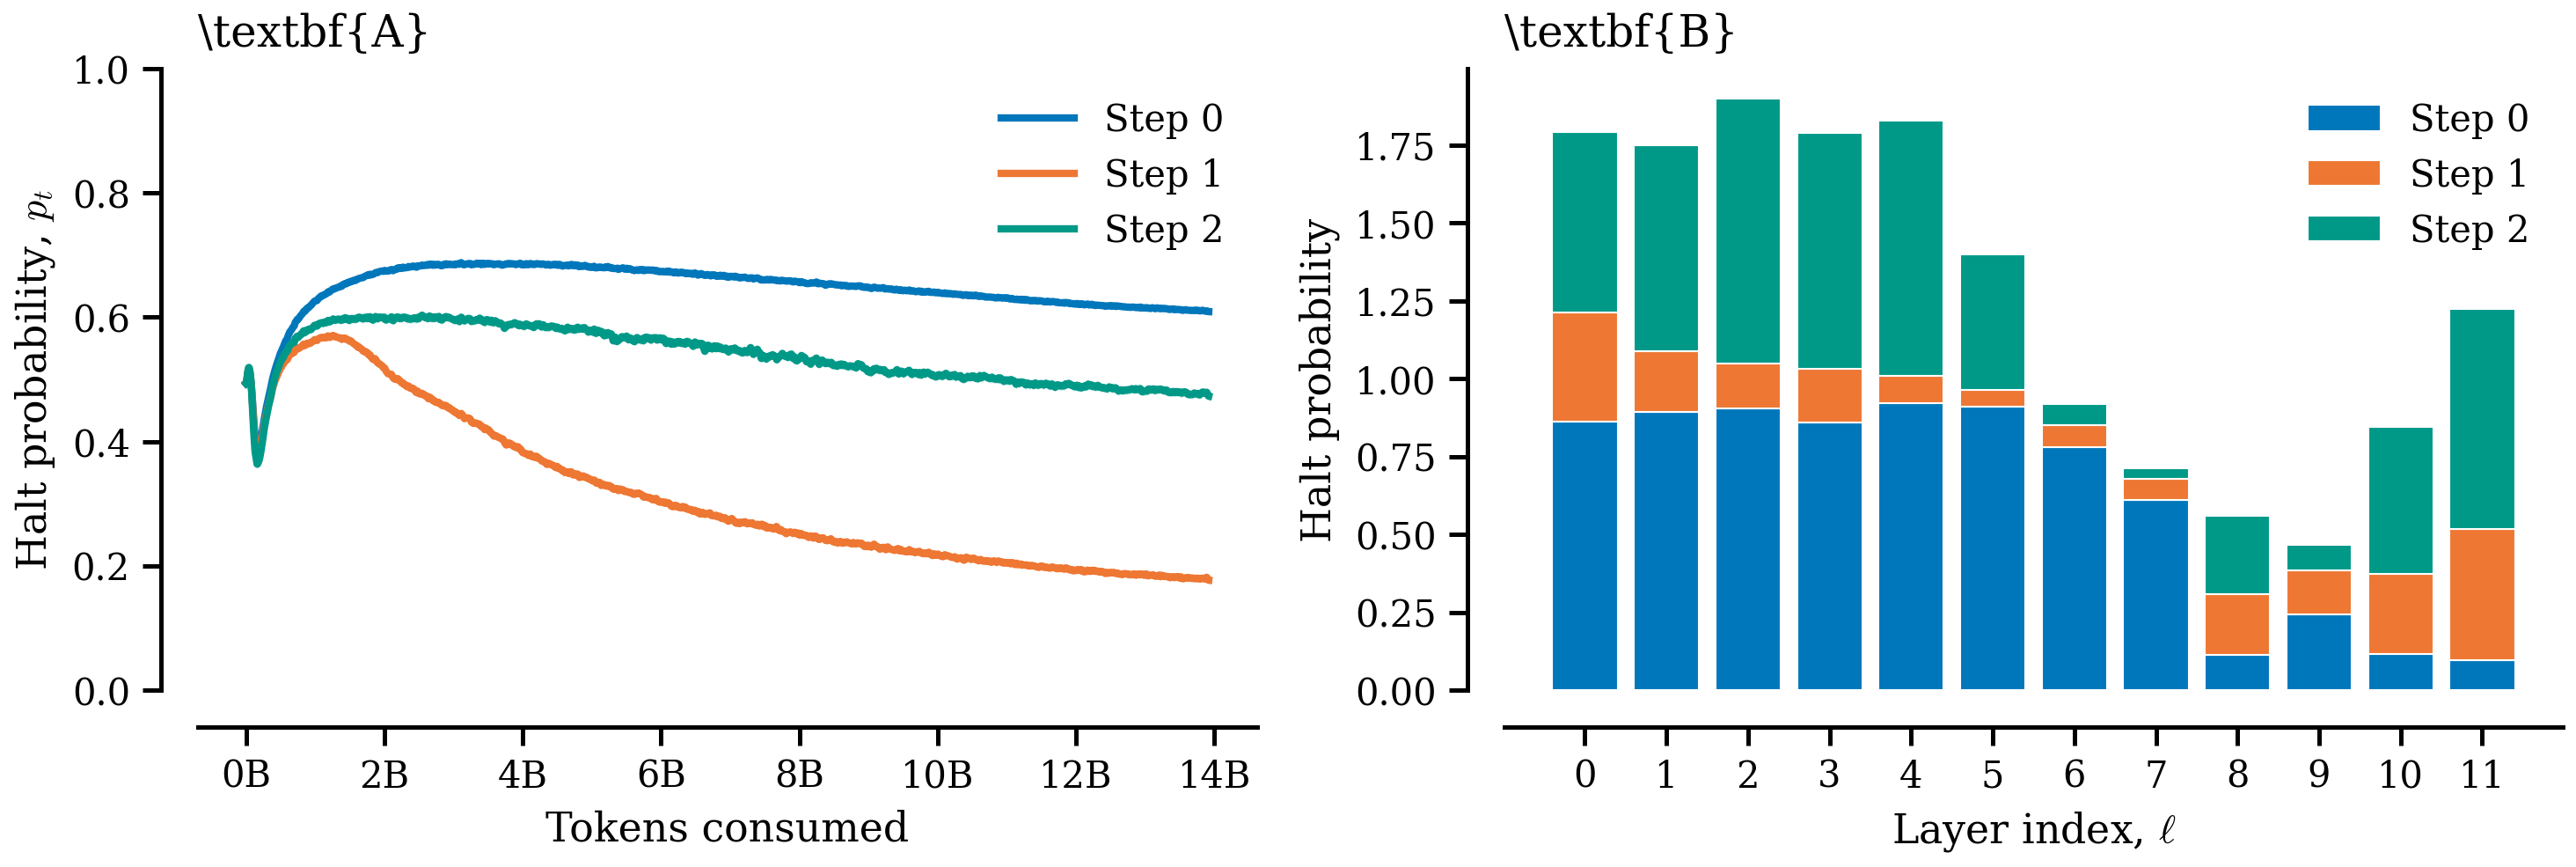

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
step_colors = [COLORS['blue'], COLORS['orange'], COLORS['teal']]

# (A) Halt prob over training
ax = axes[0]
for t in range(MAX_LOOPS):
    col = f'train adaptive/avg_halt_prob_step_{t}'
    if col in df.columns:
        # === CHANGE: Use df['tokens'] ===
        plot_with_band(ax, df['tokens'], df[col], step_colors[t], 
                      label=rf'Step {t}', smooth_sigma=20)
format_token_axis(ax) # === CHANGE: Apply formatter
ax.set_ylabel(r'Halt probability, $p_t$')
ax.set_title(r'\textbf{A}', loc='left')
ax.legend()
ax.set_ylim(0, 1)

# (B) Stacked bar by layer (No changes needed except running it)
ax = axes[1]
halt_matrix = np.zeros((NUM_LAYERS, MAX_LOOPS))
for layer in range(NUM_LAYERS):
    for t in range(MAX_LOOPS):
        col = f'train layers/{layer}/halt_prob_{t}'
        if col in df.columns:
            halt_matrix[layer, t] = df[col].iloc[-100:].mean()

x = np.arange(NUM_LAYERS)
bottom = np.zeros(NUM_LAYERS)
for t in range(MAX_LOOPS):
    ax.bar(x, halt_matrix[:, t], bottom=bottom, 
           label=rf'Step {t}', color=step_colors[t],
           edgecolor='white', linewidth=0.5)
    bottom += halt_matrix[:, t]
ax.set_xlabel(r'Layer index, $\ell$')
ax.set_ylabel(r'Halt probability')
ax.set_title(r'\textbf{B}', loc='left')
ax.legend()
ax.set_xticks(x)

despine(axes)
plt.tight_layout()
save_figure(fig, 'halt_distribution', FIGURES_DIR)
plt.show()

---
## 7. Expected Steps Evolution

**Claim:** *"Model uses additional loops as soon as it learns simple grammatical structures"*

  → Saved: expected_steps.{pdf, png}


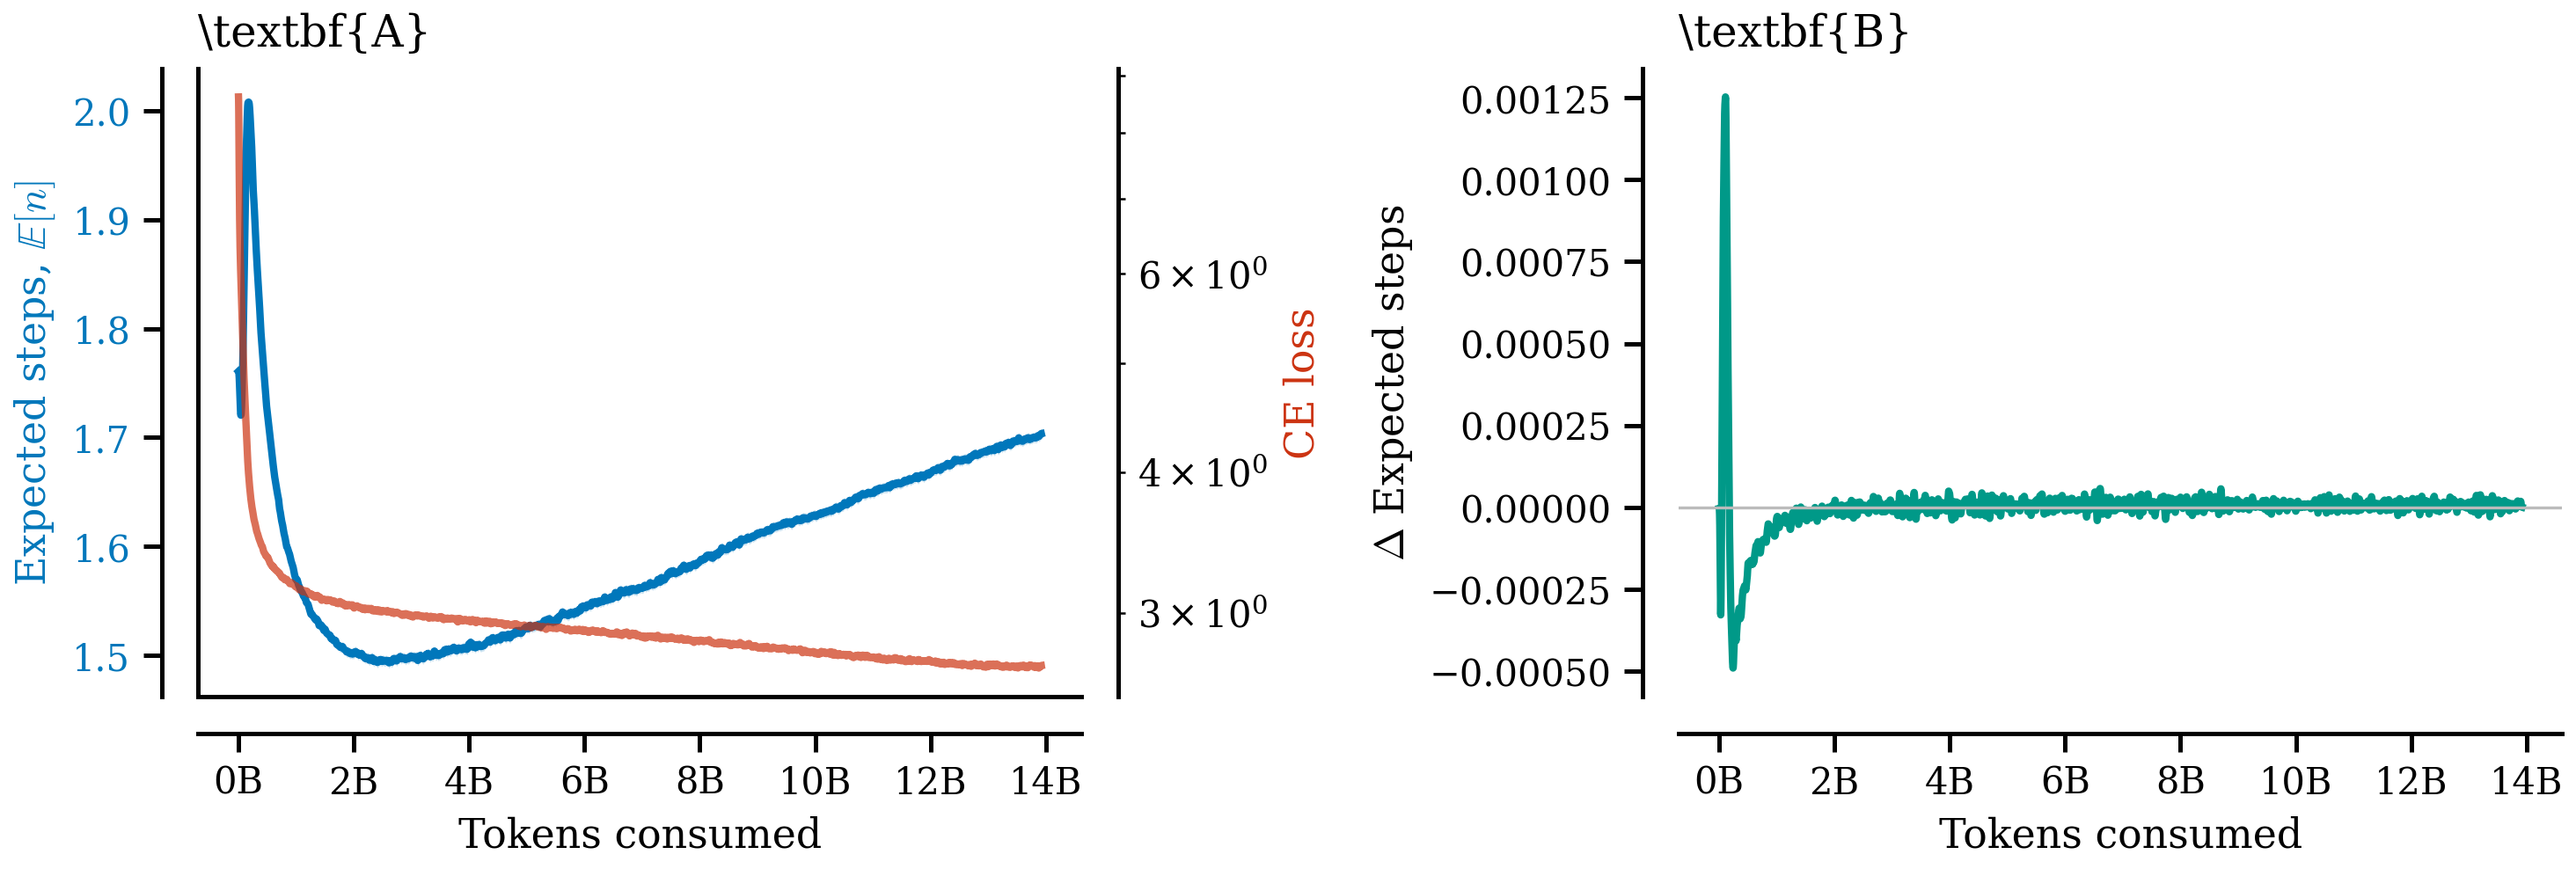

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

expected = safe_get('train adaptive/expected_steps_avg')
ce = safe_get('train loss/ce_avg')

# (A) Expected steps with loss overlay
ax1 = axes[0]
ax2 = ax1.twinx()

# === CHANGE: Use df['tokens'] ===
plot_with_band(ax1, df['tokens'], expected, COLORS['blue'], smooth_sigma=20)
format_token_axis(ax1) # === CHANGE: Apply formatter
ax1.set_ylabel(r'Expected steps, $\mathbb{E}[n]$', color=COLORS['blue'])
ax1.tick_params(axis='y', labelcolor=COLORS['blue'])

ce_smooth = smooth(ce.fillna(method='ffill').values, sigma=20)
# === CHANGE: Use df['tokens'] ===
ax2.plot(df['tokens'], ce_smooth, color=COLORS['red'], alpha=0.7, linewidth=2)
ax2.set_ylabel(r'CE loss', color=COLORS['red'])
ax2.tick_params(axis='y', labelcolor=COLORS['red'])
ax2.set_yscale('log')
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_position(('outward', 10))

ax1.set_title(r'\textbf{A}', loc='left')

# (B) Rate of change
ax = axes[1]
window = min(100, len(expected) // 10)
if window > 1:
    smoothed = expected.rolling(window=window, center=True).mean()
    deriv = smoothed.diff()
    deriv_smooth = smooth(deriv.fillna(0).values, sigma=20)
    
    # === CHANGE: Use df['tokens'] ===
    ax.fill_between(df['tokens'], 0, np.clip(deriv_smooth, 0, None), 
                    color=COLORS['teal'], alpha=0.3, linewidth=0)
    ax.plot(df['tokens'], deriv_smooth, color=COLORS['teal'], linewidth=2)
    ax.axhline(0, color=COLORS['grey'], ls='-', lw=0.8)

format_token_axis(ax) # === CHANGE: Apply formatter
ax.set_ylabel(r'$\Delta$ Expected steps')
ax.set_title(r'\textbf{B}', loc='left')

despine(ax1)
despine(axes[1])

plt.tight_layout()
save_figure(fig, 'expected_steps', FIGURES_DIR)
plt.show()